In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pathlib
import json

# ── Répertoires ──────────────────────────────────────────
DATA_DIR   = pathlib.Path("./")
OUTPUT_DIR = pathlib.Path("plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Style publication ────────────────────────────────────
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size"         : 11,
    "axes.labelsize"    : 11,
    "legend.fontsize"   : 9,
    "xtick.labelsize"   : 9,
    "ytick.labelsize"   : 9,
    "figure.dpi"        : 300,
    "savefig.bbox"      : "tight",
    "savefig.format"    : "png",
    "axes.grid"         : True,
    "grid.alpha"        : 0.3,
})

# ── Chargement ───────────────────────────────────────────
df      = pd.read_csv(DATA_DIR / "summary.csv")
df_iter = pd.read_csv(DATA_DIR / "iterations.csv")
with open(DATA_DIR / "instances.json") as f:
    instances = pd.DataFrame(json.load(f))

# ── Labels LaTeX ─────────────────────────────────────────
NICE = {
    "best_a1.0_r5":        r"best",
    "multistart_a0.3_r5":  r"multi $\alpha=0.3$",
    "multistart_a0.5_r5":  r"multi $\alpha=0.5$",
    "multistart_a0.7_r5":  r"multi $\alpha=0.7$",
    "multistart_a1.0_r5":  r"multi $\alpha=1.0$",
    "multistart_a1.0_r0":  r"multi $r=0$",
    "multistart_a1.0_r2":  r"multi $r=2$",
    "multistart_a1.0_r10": r"multi $r=10$",
}
df["label"]      = df["config_key"].map(NICE)
df_iter["label"] = df_iter["config_key"].map(NICE)

ORDER_ALPHA  = [r"best", r"multi $\alpha=0.3$", r"multi $\alpha=0.5$",
                r"multi $\alpha=0.7$", r"multi $\alpha=1.0$"]
ORDER_RANDOM = [r"best", r"multi $r=0$", r"multi $r=2$",
                r"multi $\alpha=1.0$", r"multi $r=10$"]
ORDER_ALL    = list(NICE.values())

PALETTE = sns.color_palette("tab10", len(NICE))
COLOR   = {lbl: PALETTE[i] for i, lbl in enumerate(NICE.values())}

def save(fig, name):
    path = OUTPUT_DIR / f"{name}.png"
    fig.savefig(path)
    print(f"Saved → {path}")
    plt.show()

In [26]:
print(df_iter[df_iter["label"] == "best"]["iter"].describe())
print(df_iter[df_iter["label"] == "best"]["iter"].value_counts().tail(10).sort_index())

count    286613.000000
mean       3894.942515
std        3172.007728
min           0.000000
25%         795.000000
50%        3505.000000
75%        6605.000000
max        9995.000000
Name: iter, dtype: float64
iter
201     1
279     1
427     1
754     1
3721    1
3939    1
4152    1
4372    1
6076    1
6208    1
Name: count, dtype: int64


In [2]:
summary_table = df.groupby("n").agg(
    instances  = ("instance_id", "nunique"),
    configs    = ("config_key",  "nunique"),
    grid_size  = ("grid_size",   "first"),
    smin       = ("smin",        "first"),
    smax       = ("smax",        "first"),
).reset_index()
summary_table["total_rows"] = summary_table["instances"] * summary_table["configs"]

fig, ax = plt.subplots(figsize=(10, 0.5 * len(summary_table) + 1.5))
ax.axis("off")
table = ax.table(
    cellText  = summary_table.values,
    colLabels = ["$n$", "Instances", "Configs", "Grid size",
                 "$s_{min}$", "$s_{max}$", "Total rows"],
    cellLoc   = "center",
    loc       = "center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
ax.set_title(r"\textbf{Dataset Description --- MSTN Benchmark}", pad=12)
save(fig, "00_dataset_description")

Saved → plots/00_dataset_description.pdf


RuntimeError: Failed to process string with tex because dvipng could not be found

<Figure size 3000x2250 with 1 Axes>

Saved → plots/01_quality_by_config.png


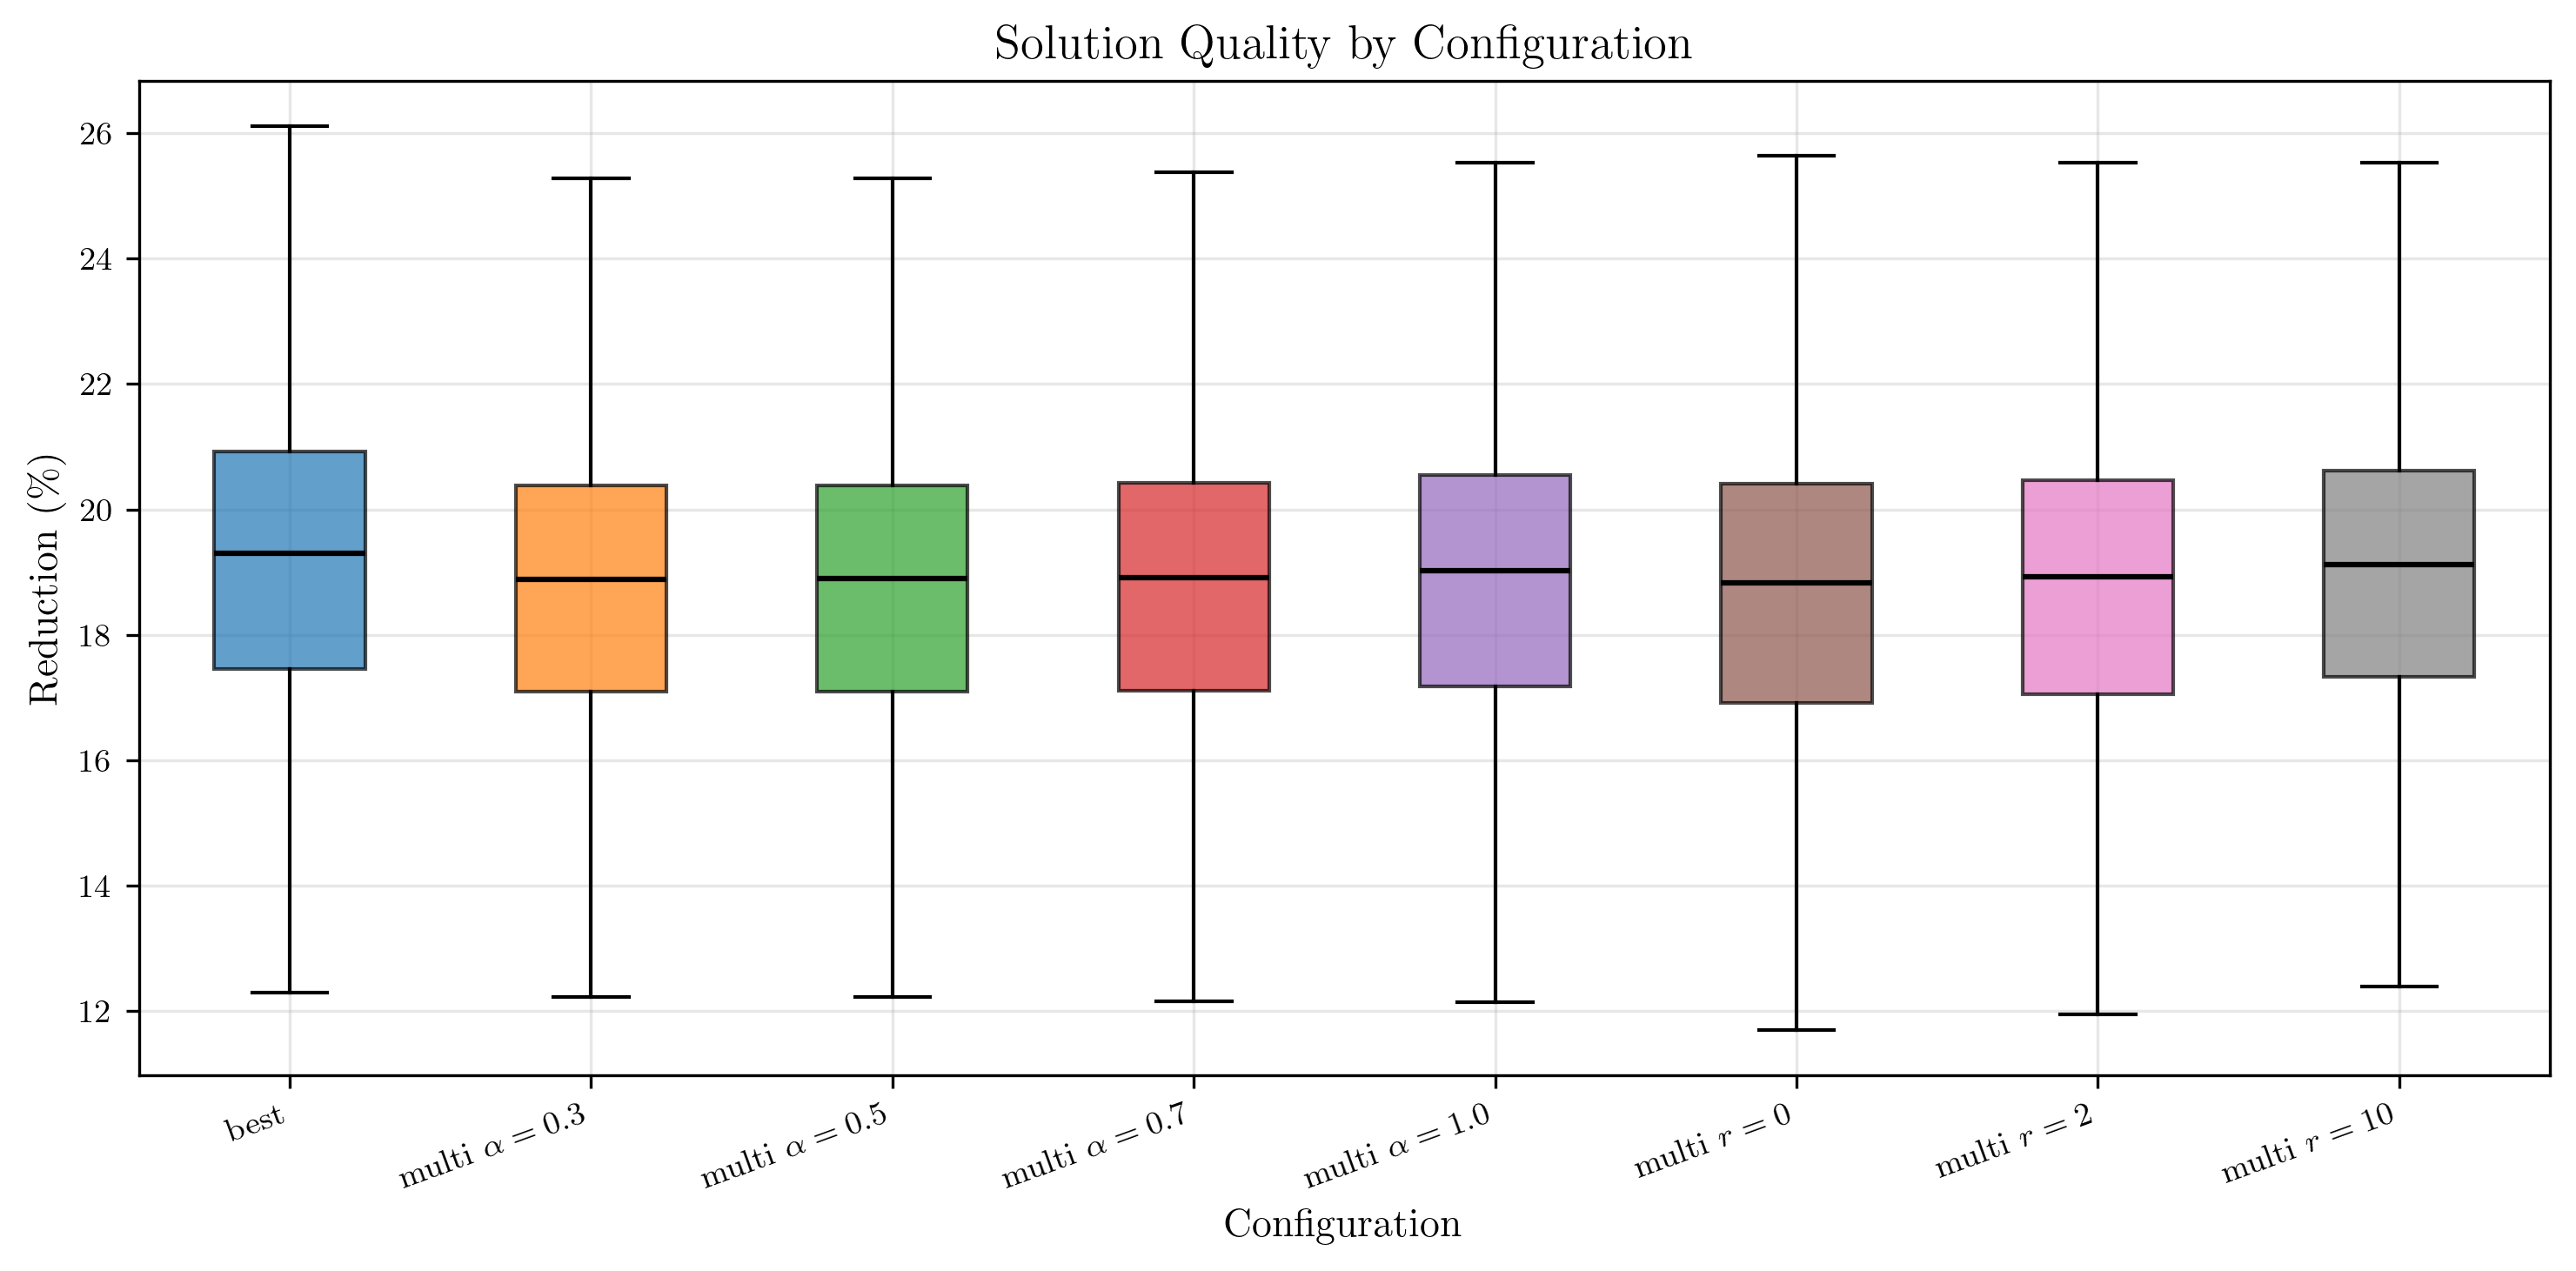

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))
data = [df[df["label"] == lbl]["reduction_pct"].dropna() for lbl in ORDER_ALL]
bp = ax.boxplot(data, tick_labels=ORDER_ALL, patch_artist=True,
                medianprops=dict(color="black", linewidth=1.5),
                showfliers=False)  # masquer outliers pour clarté
for patch, lbl in zip(bp["boxes"], ORDER_ALL):
    patch.set_facecolor(COLOR[lbl])
    patch.set_alpha(0.7)
ax.set_xlabel("Configuration")
ax.set_ylabel(r"Reduction (\%)")
ax.set_title("Solution Quality by Configuration")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
save(fig, "01_quality_by_config")
plt.show()

Saved → plots/02_reduction_vs_n.png


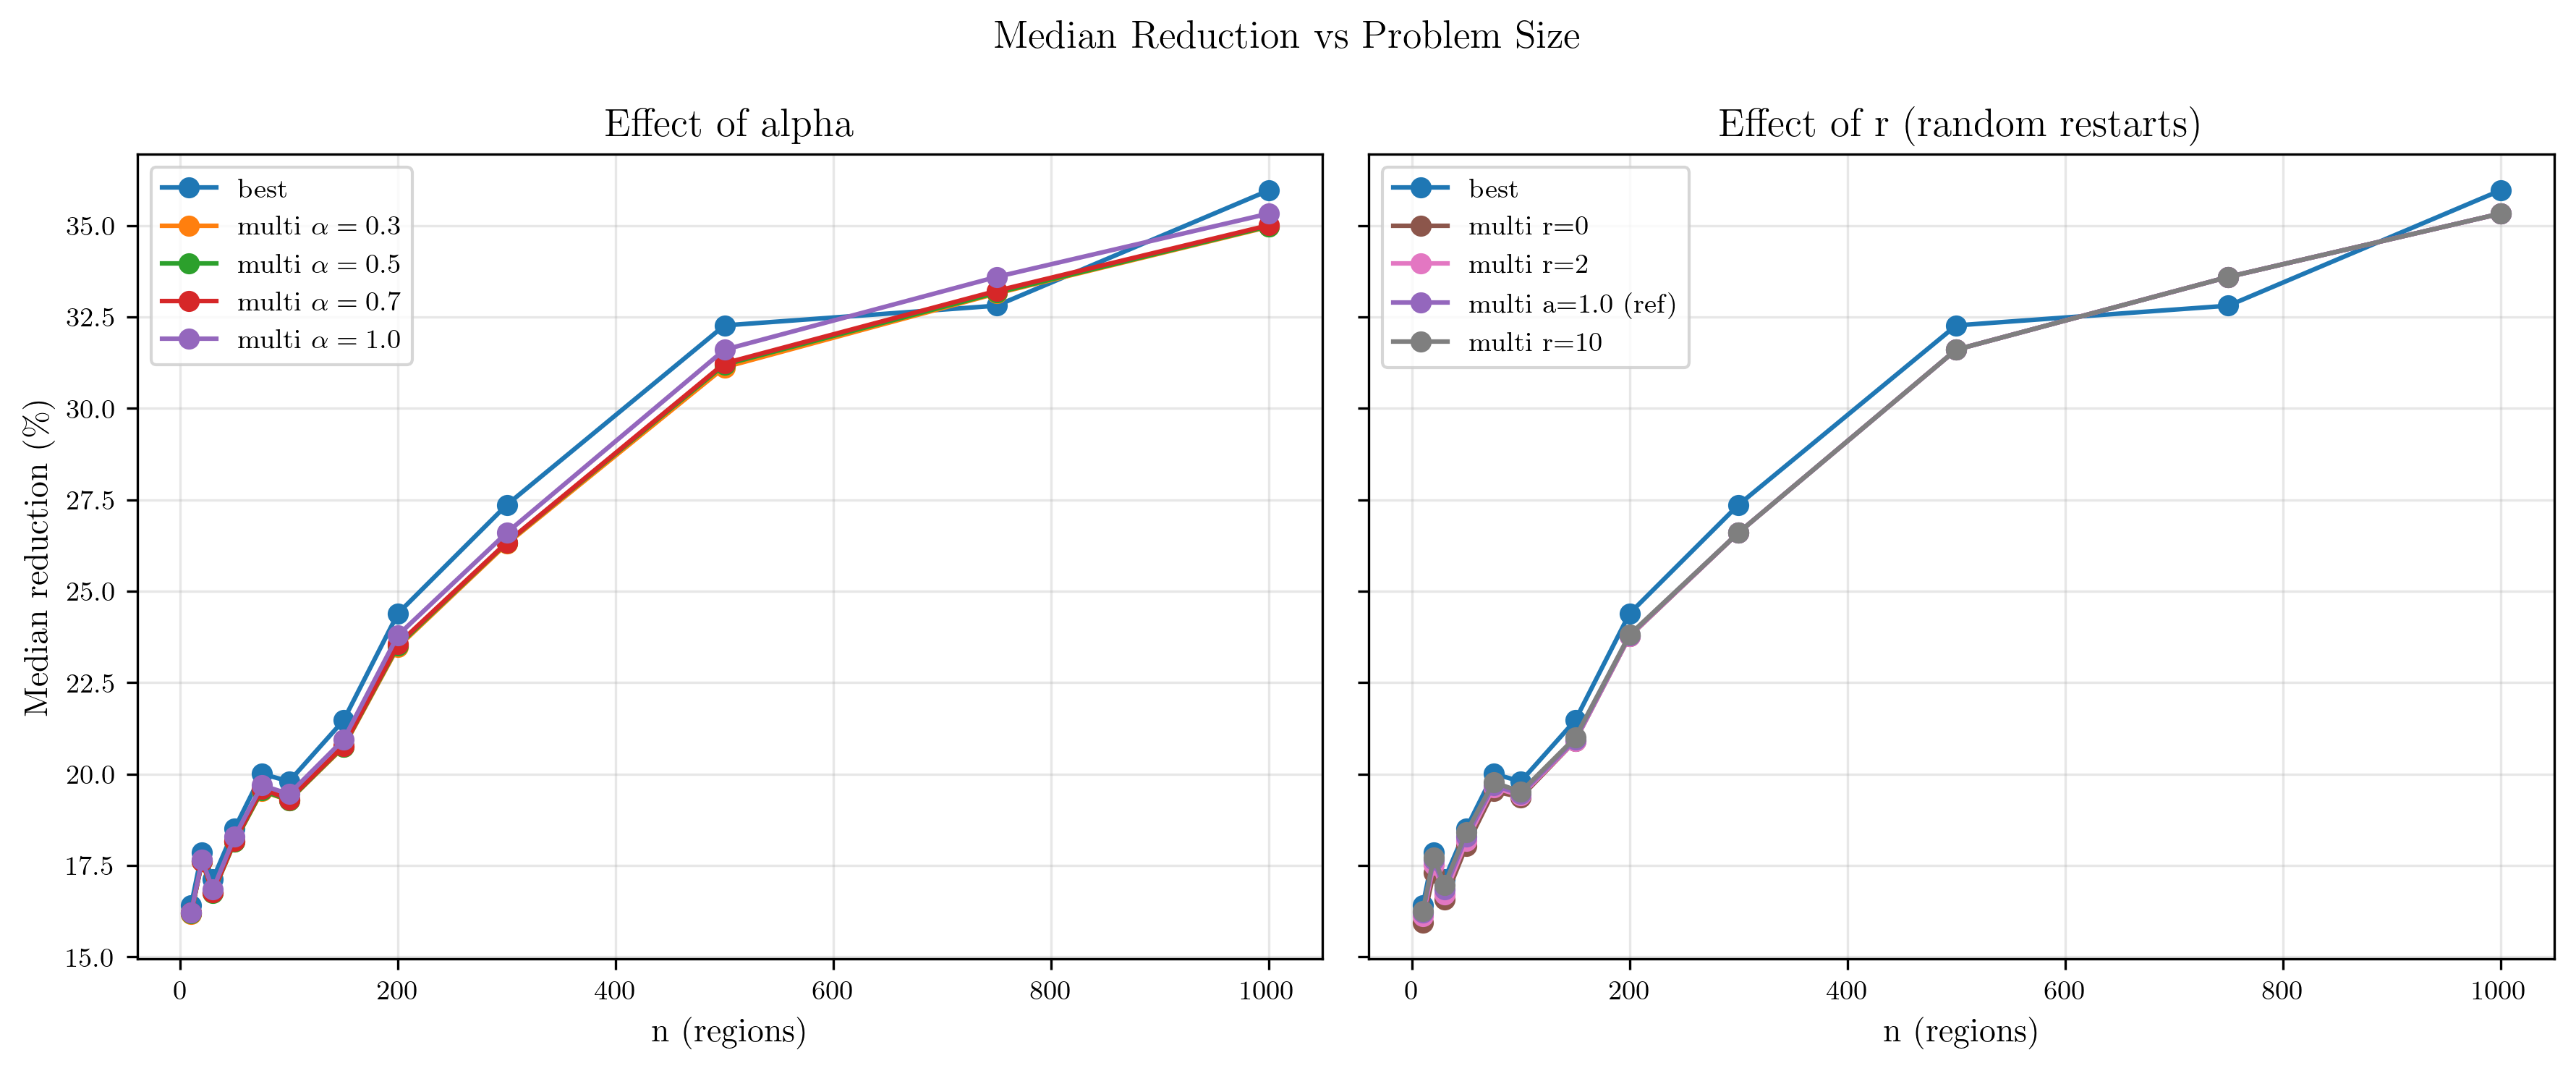

In [43]:
med = df.groupby(["n","label"])["reduction_pct"].median().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Axe gauche : effet alpha
for lbl in ORDER_ALPHA:
    sub = med[med["label"] == lbl].sort_values("n")
    axes[0].plot(sub["n"], sub["reduction_pct"], marker="o",
                 label=lbl, color=COLOR[lbl])
axes[0].set_xlabel("n (regions)")
axes[0].set_ylabel(r"Median reduction (\%)")
axes[0].set_title("Effect of alpha")
axes[0].legend()

# Axe droit : effet n_random (renommer le label de référence)
ORDER_RANDOM_FIX = ["best", "multi r=0", "multi r=2", "multi a=1.0 (ref)", "multi r=10"]
for orig_lbl, display_lbl in zip(ORDER_RANDOM, ORDER_RANDOM_FIX):
    sub = med[med["label"] == orig_lbl].sort_values("n")
    axes[1].plot(sub["n"], sub["reduction_pct"], marker="o",
                 label=display_lbl, color=COLOR[orig_lbl])
axes[1].set_xlabel("n (regions)")
axes[1].set_title("Effect of r (random restarts)")
axes[1].legend()

fig.suptitle("Median Reduction vs Problem Size", fontsize=13)
plt.tight_layout()
save(fig, "02_reduction_vs_n")
plt.show()

Saved → plots/03_iters_vs_n.png


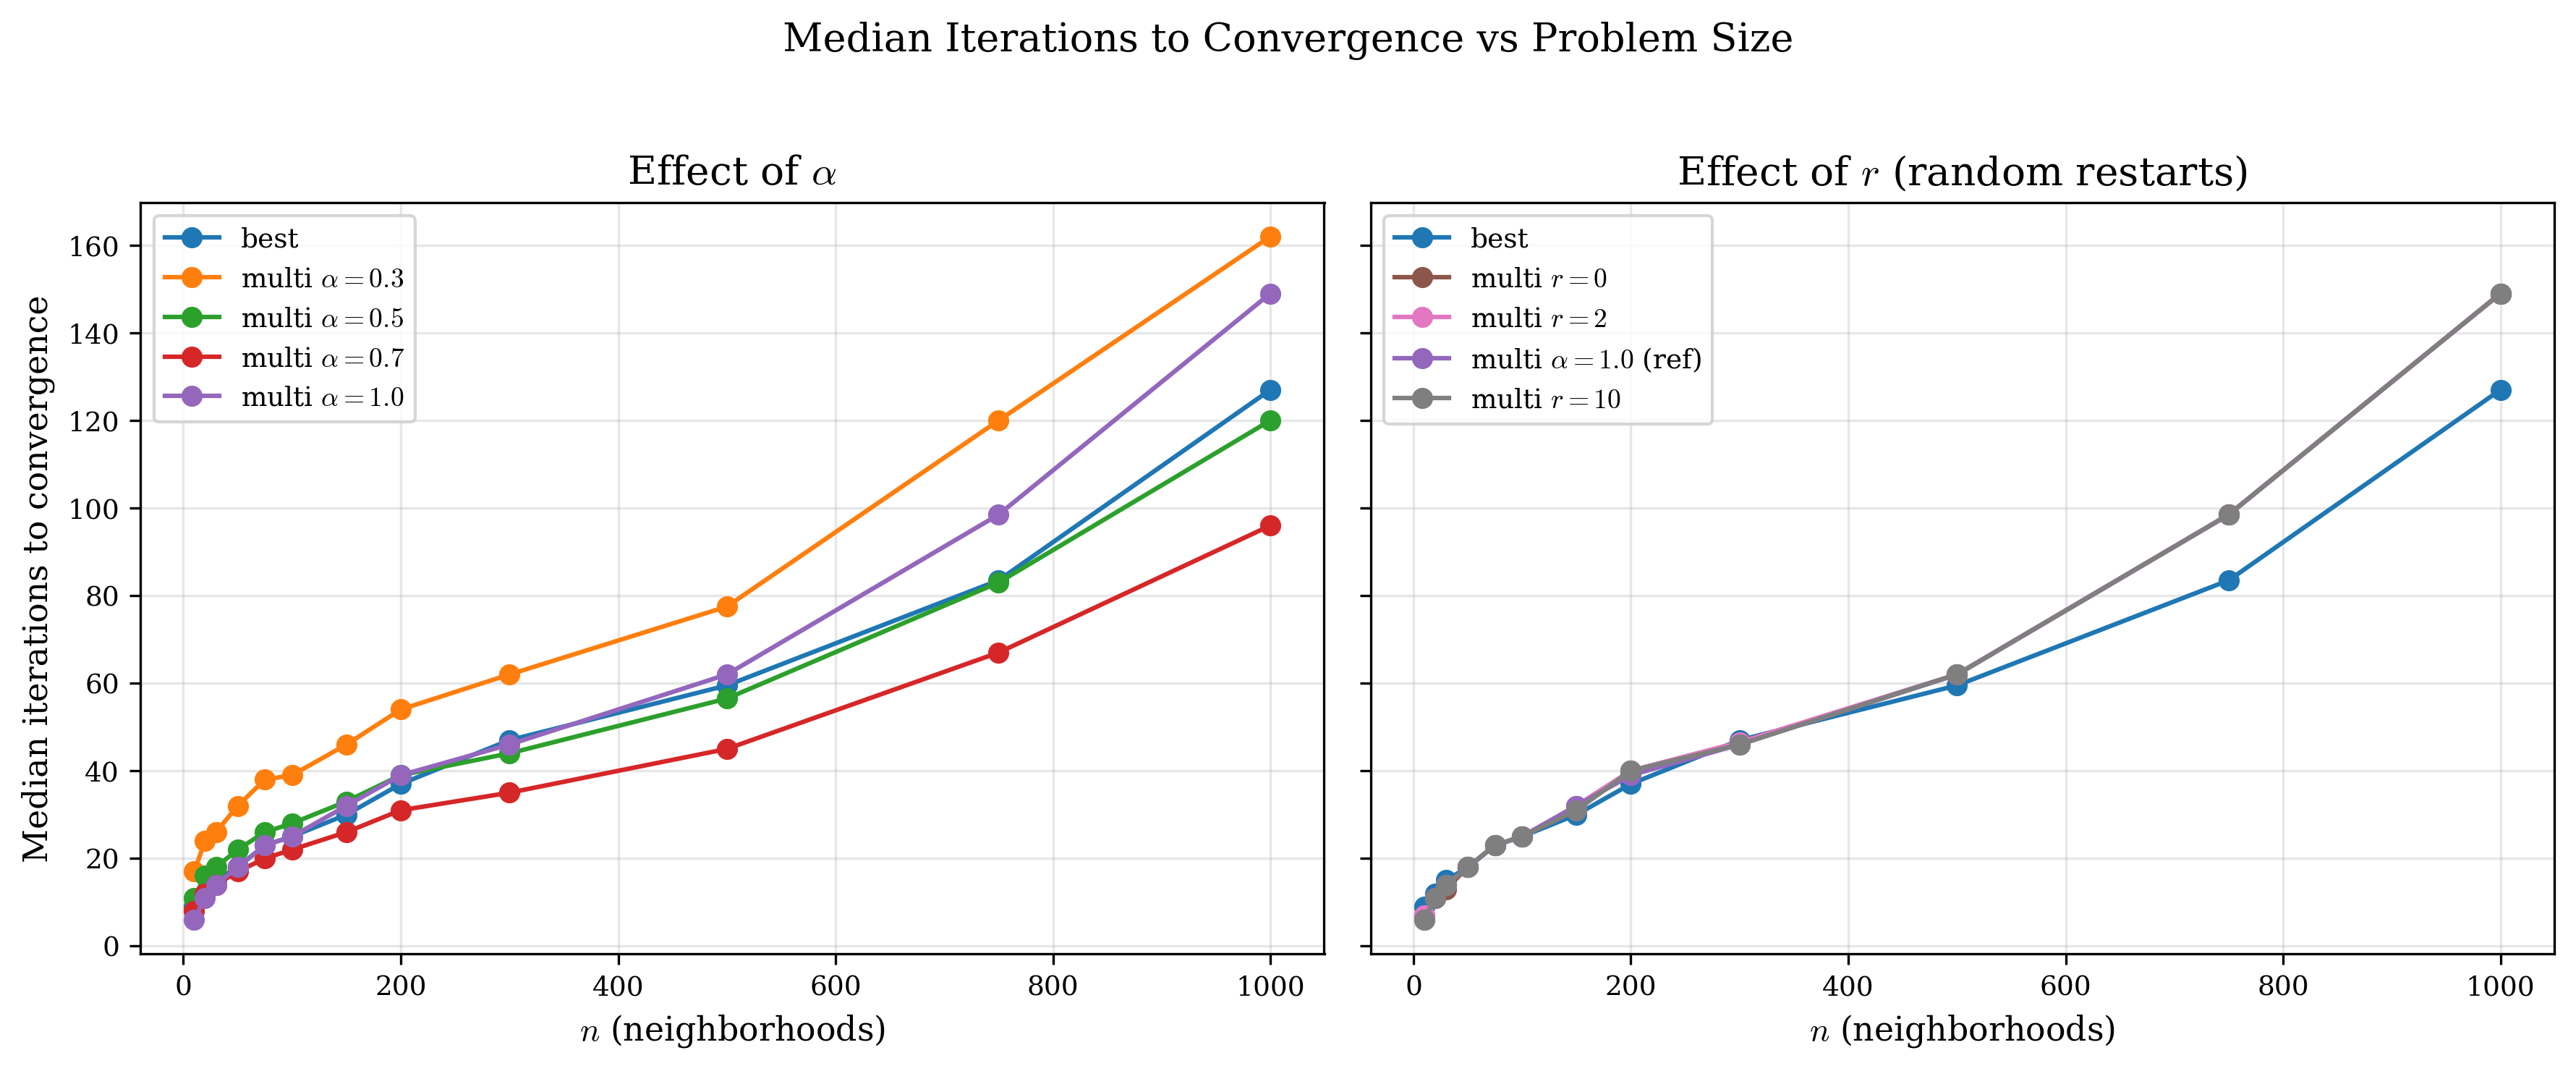

In [19]:
med = df.groupby(["n", "label"])["n_iters"].median().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Panneau gauche : effet alpha
for lbl in ORDER_ALPHA:
    sub = med[med.label == lbl].sort_values("n")
    axes[0].plot(sub.n, sub.n_iters, marker="o", label=lbl, color=COLOR[lbl])
axes[0].set_xlabel("$n$ (neighborhoods)")
axes[0].set_ylabel("Median iterations to convergence")
axes[0].set_title("Effect of $\\alpha$")
axes[0].legend()

# Panneau droit : effet r
ORDER_RANDOM_FIX = [
    "best", "multi $r=0$", "multi $r=2$",
    "multi $\\alpha=1.0$ (ref)", "multi $r=10$"
]
for orig_lbl, disp_lbl in zip(ORDER_RANDOM, ORDER_RANDOM_FIX):
    sub = med[med.label == orig_lbl].sort_values("n")
    axes[1].plot(sub.n, sub.n_iters, marker="o",
                 label=disp_lbl, color=COLOR[orig_lbl])
axes[1].set_xlabel("$n$ (neighborhoods)")
axes[1].set_title("Effect of $r$ (random restarts)")
axes[1].legend()

fig.suptitle(
    "Median Iterations to Convergence vs Problem Size\n",
    fontsize=13
)
plt.tight_layout()
save(fig, "03_iters_vs_n")
plt.show()

Saved → plots/04_runtime_vs_n.png


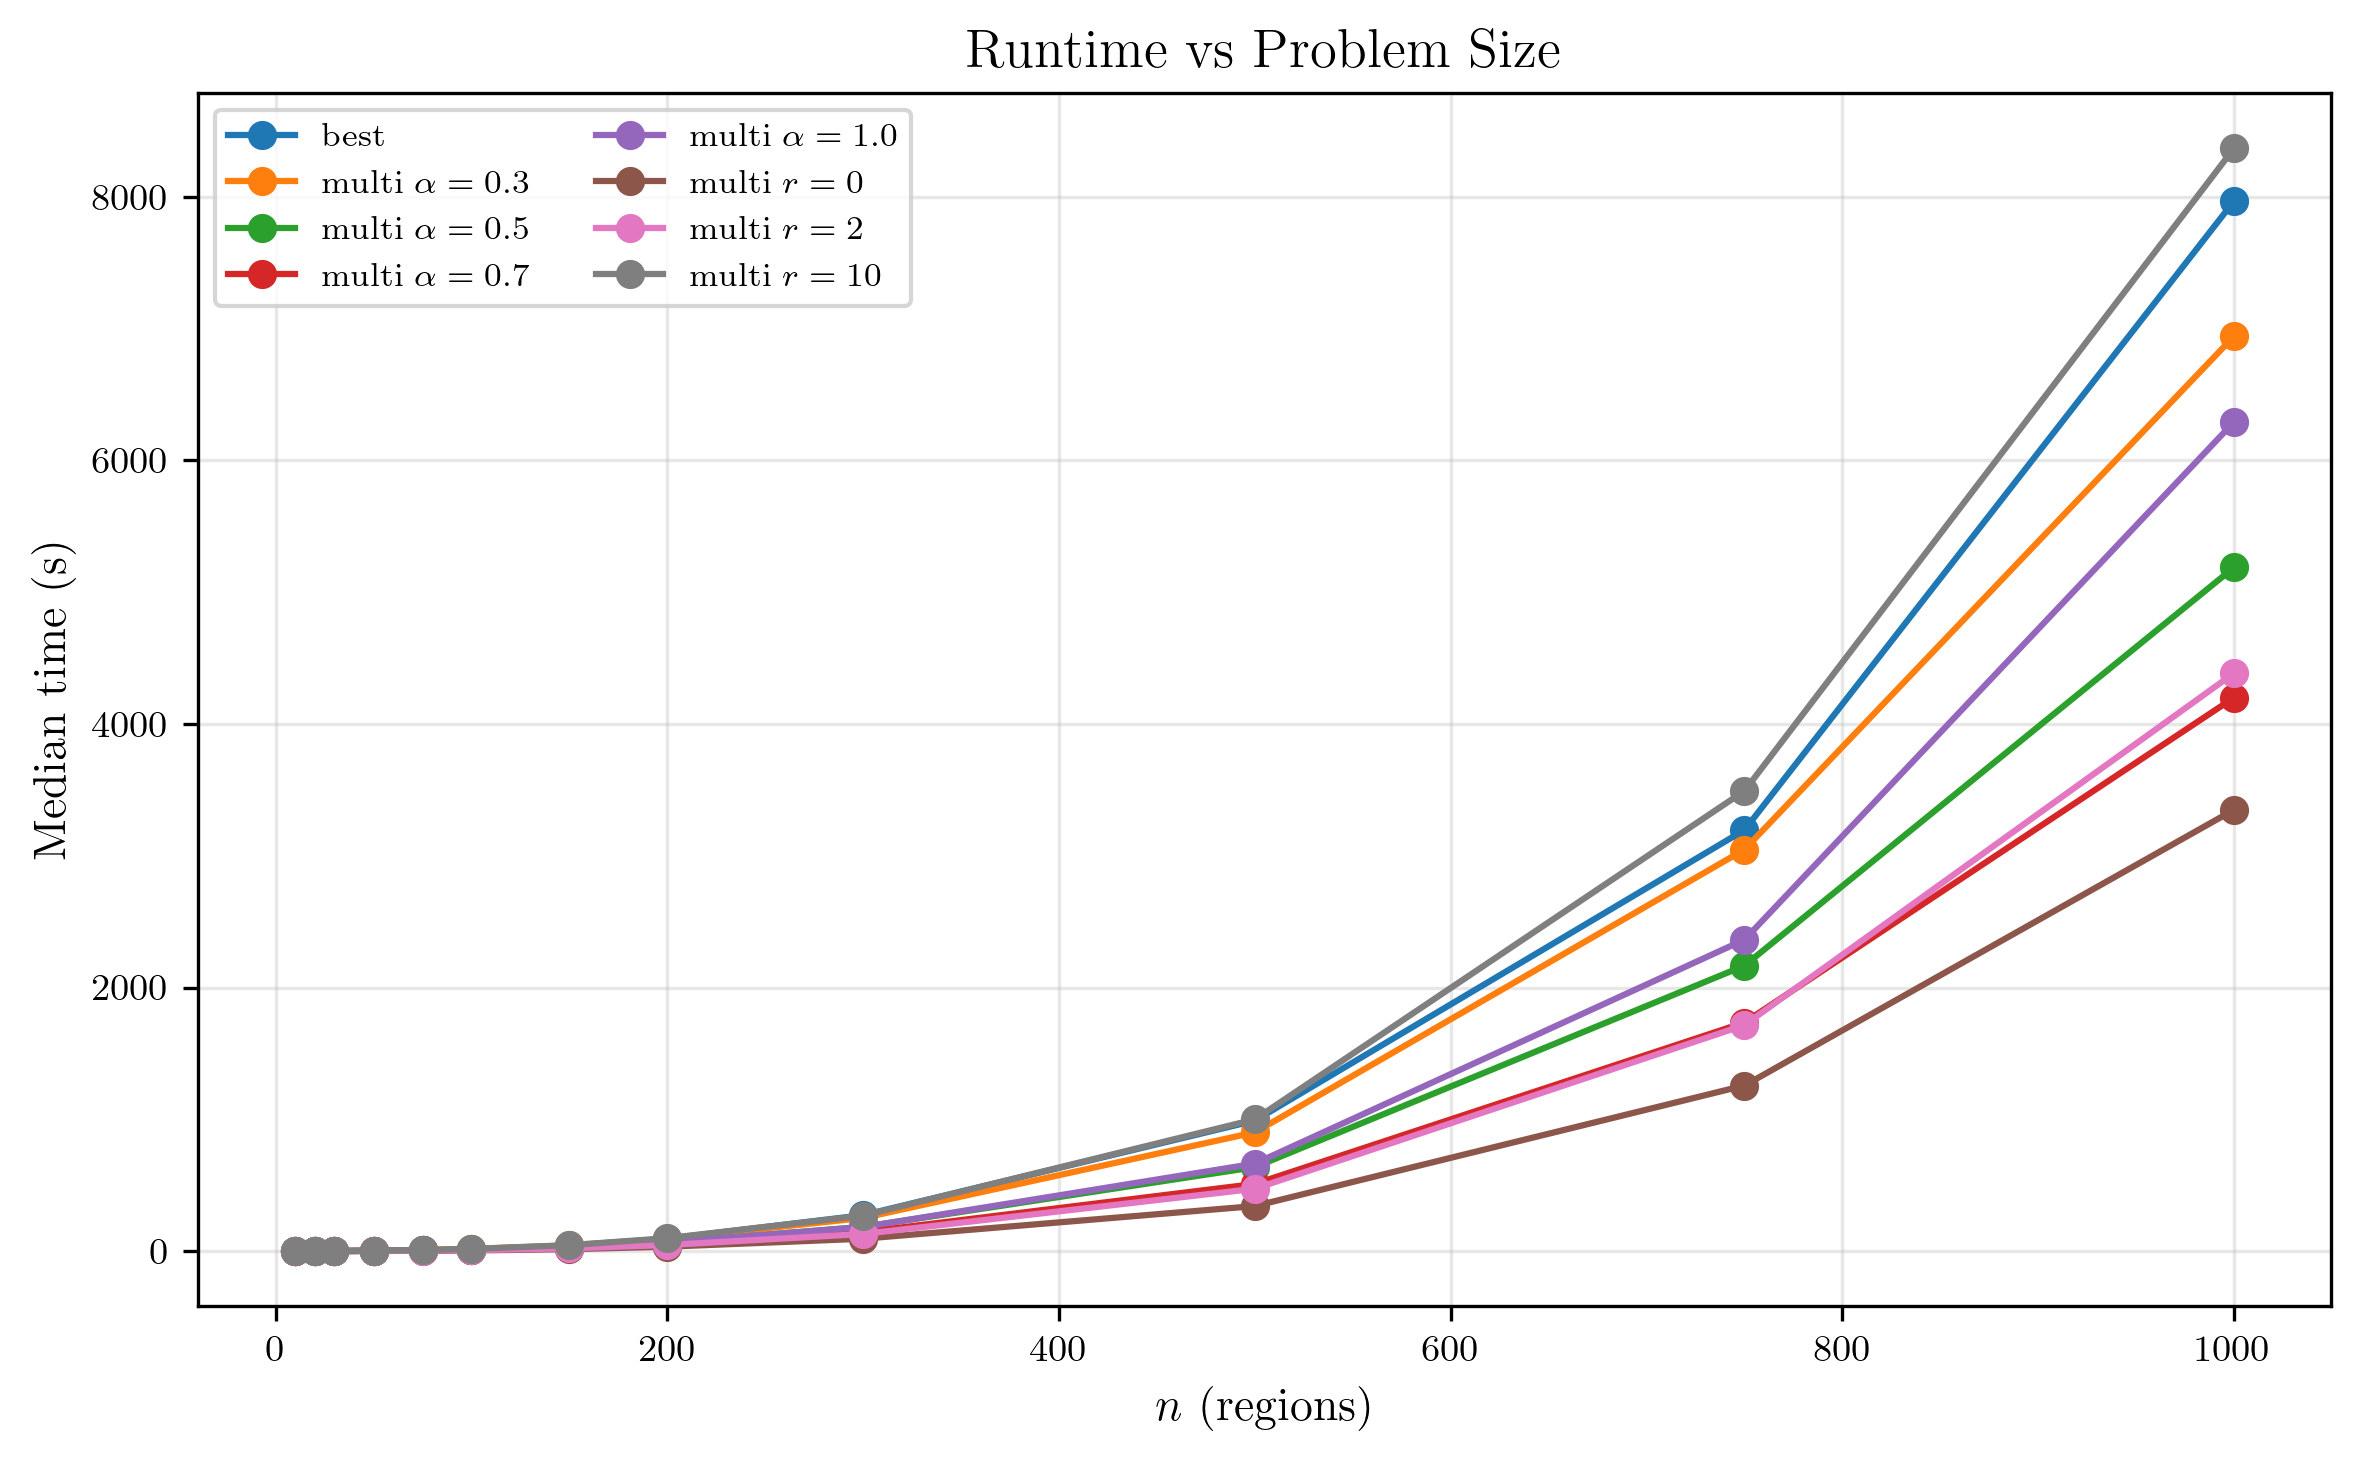

In [25]:
med_time = df.groupby(["n","label"])["time_s"].median().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
for lbl in ORDER_ALL:
    sub = med_time[med_time["label"] == lbl].sort_values("n")
    ax.plot(sub["n"], sub["time_s"], marker="o", label=lbl, color=COLOR[lbl])

ax.set_xlabel(r"$n$ (regions)")
ax.set_ylabel(r"Median time (s)")
ax.set_title(r"Runtime vs Problem Size")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
save(fig, "04_runtime_vs_n")
plt.show()

Saved → plots/05_performance_profile.png


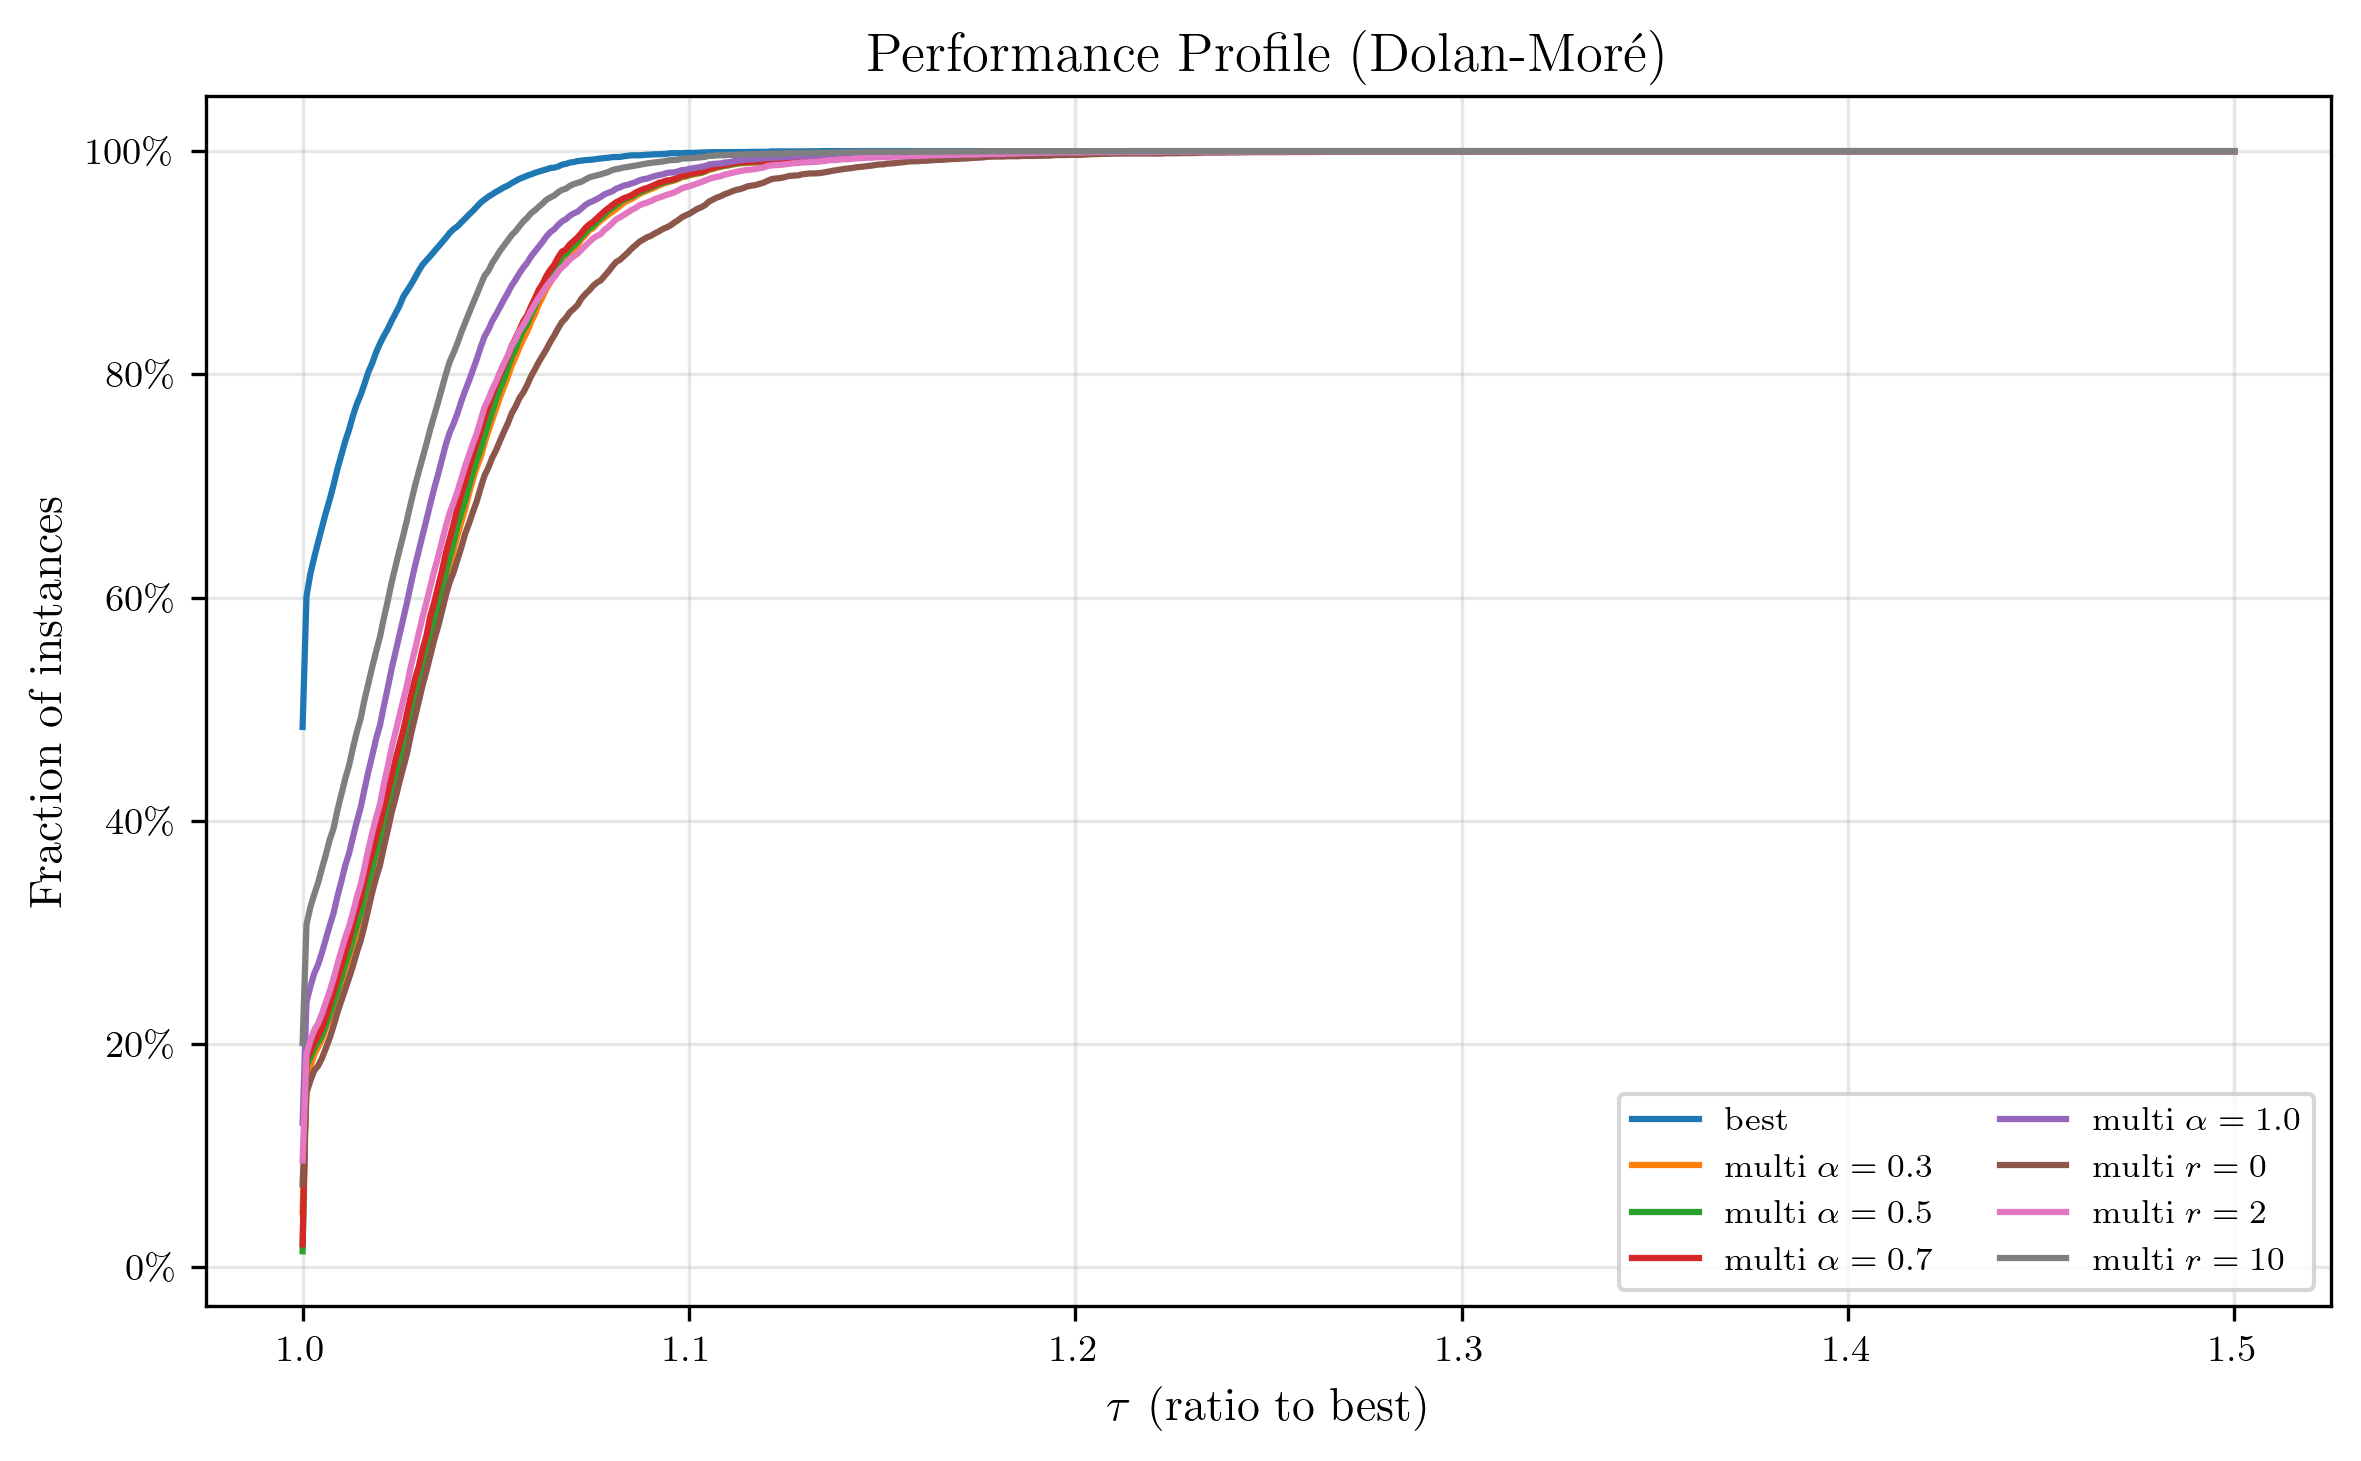

In [45]:
pivot     = df.pivot_table(index="instance_id", columns="config_key", values="reduction_pct")
best_inst = pivot.max(axis=1)
tau_vals  = np.linspace(1.0, 1.5, 500)

fig, ax = plt.subplots(figsize=(8, 5))
for cfg, lbl in NICE.items():
    if cfg not in pivot.columns:
        continue
    ratios  = best_inst / pivot[cfg].clip(lower=1e-9)
    profile = [(ratios <= tau).mean() for tau in tau_vals]
    ax.plot(tau_vals, profile, label=lbl, color=COLOR[lbl])

ax.set_xlabel(r"$\tau$ (ratio to best)")
ax.set_ylabel(r"Fraction of instances")
ax.set_title(r"Performance Profile (Dolan-Mor\'e)")
ax.legend(fontsize=8, ncol=2)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
plt.tight_layout()
save(fig, "05_performance_profile")
plt.show()

Saved → plots/07_spatial_stacked_n_fixed.png


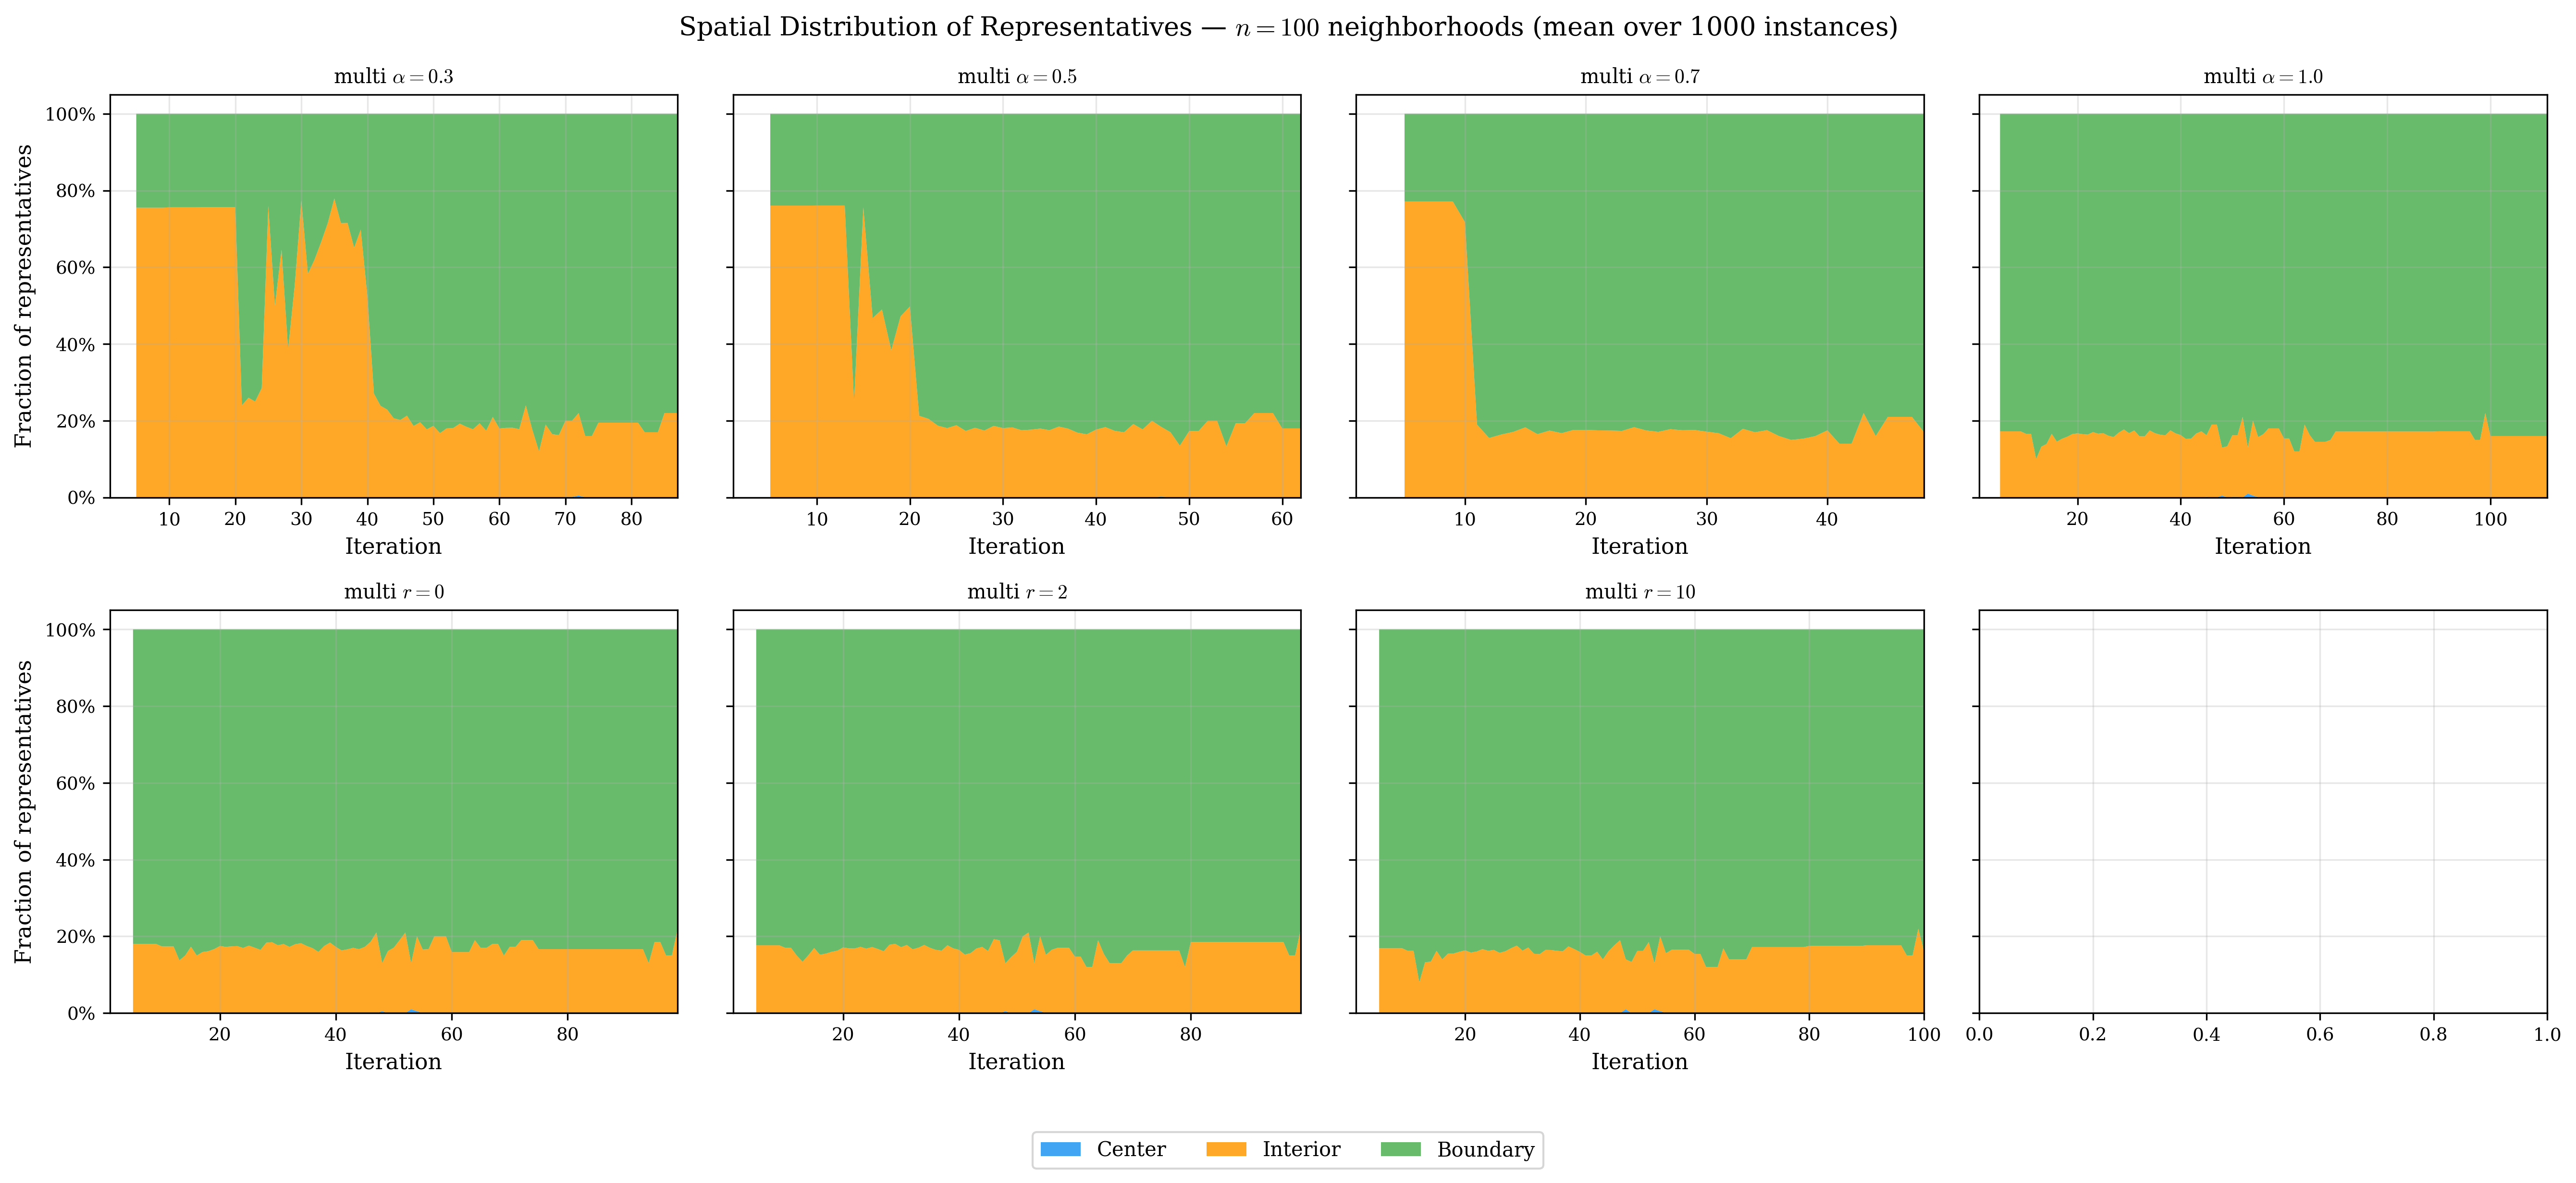

In [31]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
axes = axes.flatten()

NICE_NO_BEST = {k: v for k, v in NICE.items() if k != "best" and k != "best_a1.0_r5"}

for idx, (cfg_key, lbl) in enumerate(NICE_NO_BEST.items()):
    ref = df_iter[(df_iter["config_key"] == cfg_key) & (df_iter["n"] == 100)]
    spatial = ref.groupby("iter")[["frac_center", "frac_interior", "frac_boundary"]].mean().reset_index()

    iter_max = spatial["iter"].max()
    spatial = (spatial
               .set_index("iter")
               .reindex(range(1, iter_max + 1))
               .ffill()
               .reset_index())

    ax = axes[idx]
    ax.stackplot(
        spatial["iter"],
        spatial["frac_center"],
        spatial["frac_interior"],
        spatial["frac_boundary"],
        labels=["Center", "Interior", "Boundary"],
        colors=["#2196F3", "#FF9800", "#4CAF50"],
        alpha=0.85,
    )
    ax.set_xlim(1, iter_max)
    ax.set_title(f"{lbl}", fontsize=10)
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    ax.set_xlabel("Iteration")
    if idx % 4 == 0:
        ax.set_ylabel("Fraction of representatives")

handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="lower center", ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.03))
fig.suptitle(r"Spatial Distribution of Representatives — $n = 100$ neighborhoods (mean over 1000 instances)", fontsize=13)
plt.tight_layout(rect=[0, 0.04, 1, 1])
save(fig, "07_spatial_stacked_n_fixed")
plt.show()

Saved → plots/08_boundary_vs_iter.png


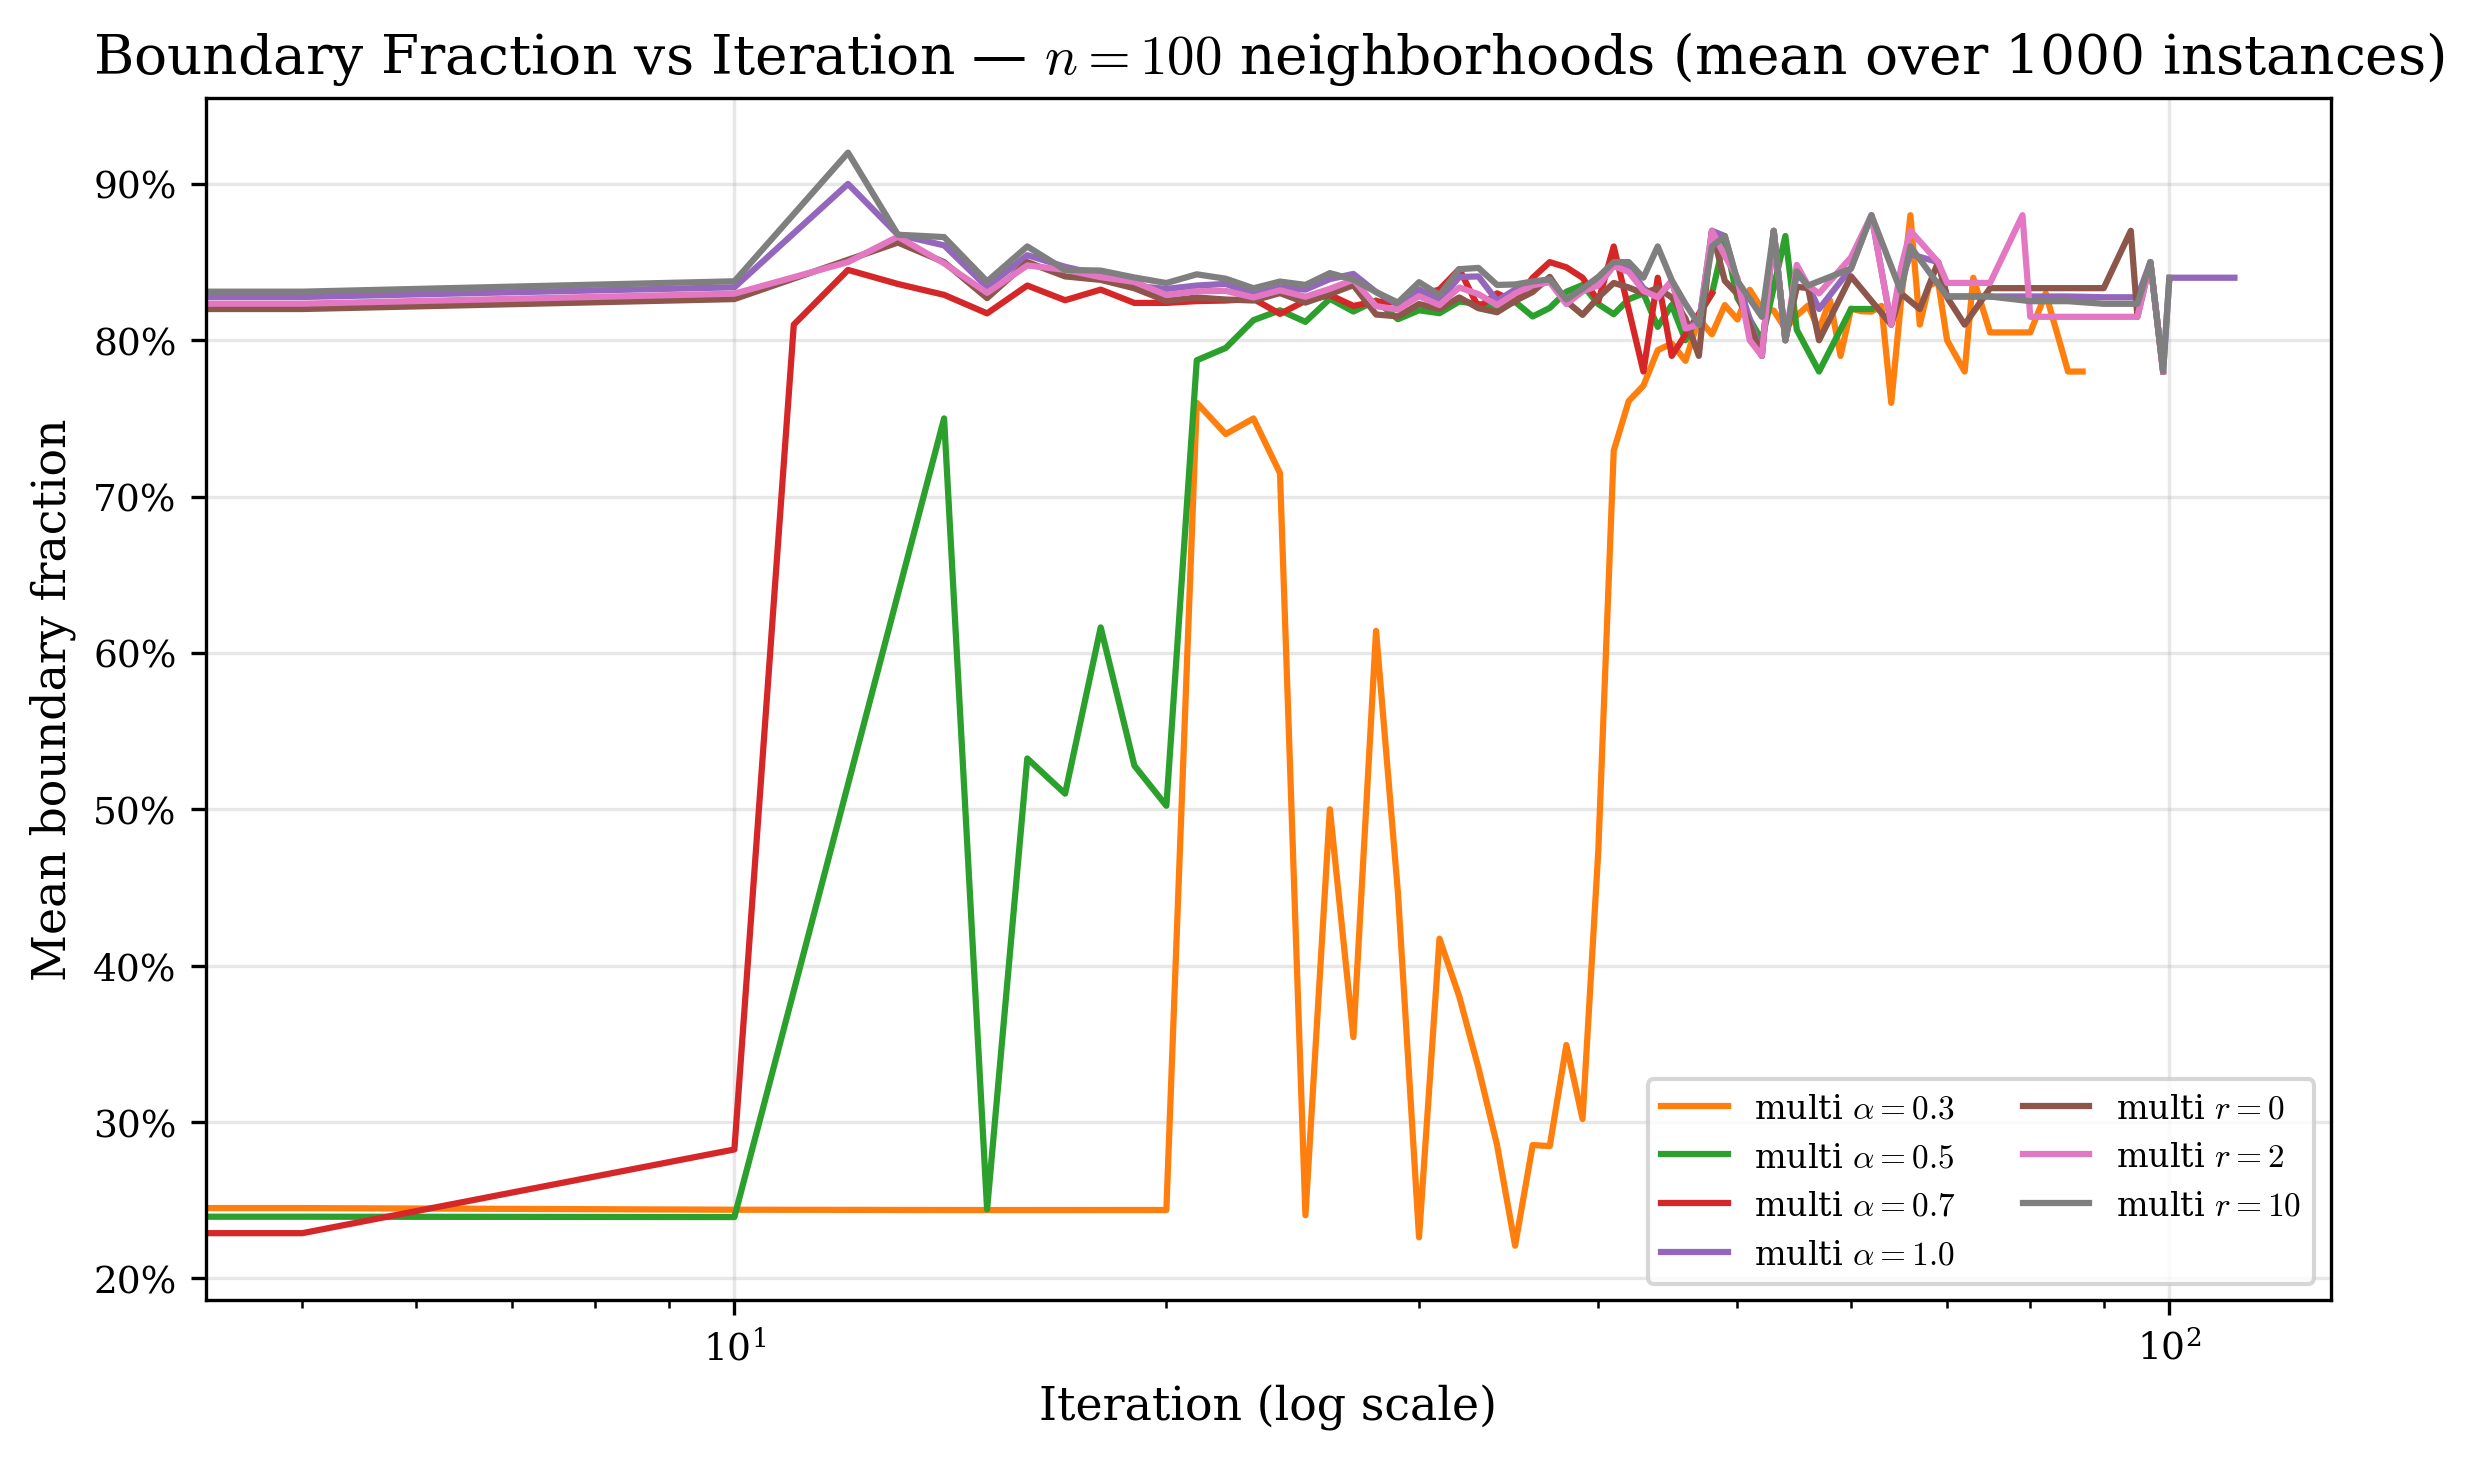

In [35]:
mean_fb = (
    df_iter[
        (df_iter["n"] == 100) &
        (~df_iter["label"].str.contains("best", na=False)) &
        (df_iter["iter"] < 9999)
    ]
    .groupby(["label", "iter"])["frac_boundary"]
    .mean()
    .reset_index()
)

ORDER_NO_BEST = [lbl for lbl in ORDER_ALL if "best" not in lbl]

fig, ax = plt.subplots(figsize=(8, 5))
for lbl in ORDER_NO_BEST:
    sub = mean_fb[mean_fb["label"] == lbl].sort_values("iter")
    ax.plot(sub["iter"], sub["frac_boundary"], label=lbl, color=COLOR[lbl])

ax.set_xscale("log")
ax.set_xlabel("Iteration (log scale)")
ax.set_ylabel("Mean boundary fraction")
ax.set_title(r"Boundary Fraction vs Iteration — $n = 100$ neighborhoods (mean over 1000 instances)")
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
save(fig, "08_boundary_vs_iter")
plt.show()

Saved → plots/09_norm_dist_vs_iter.png


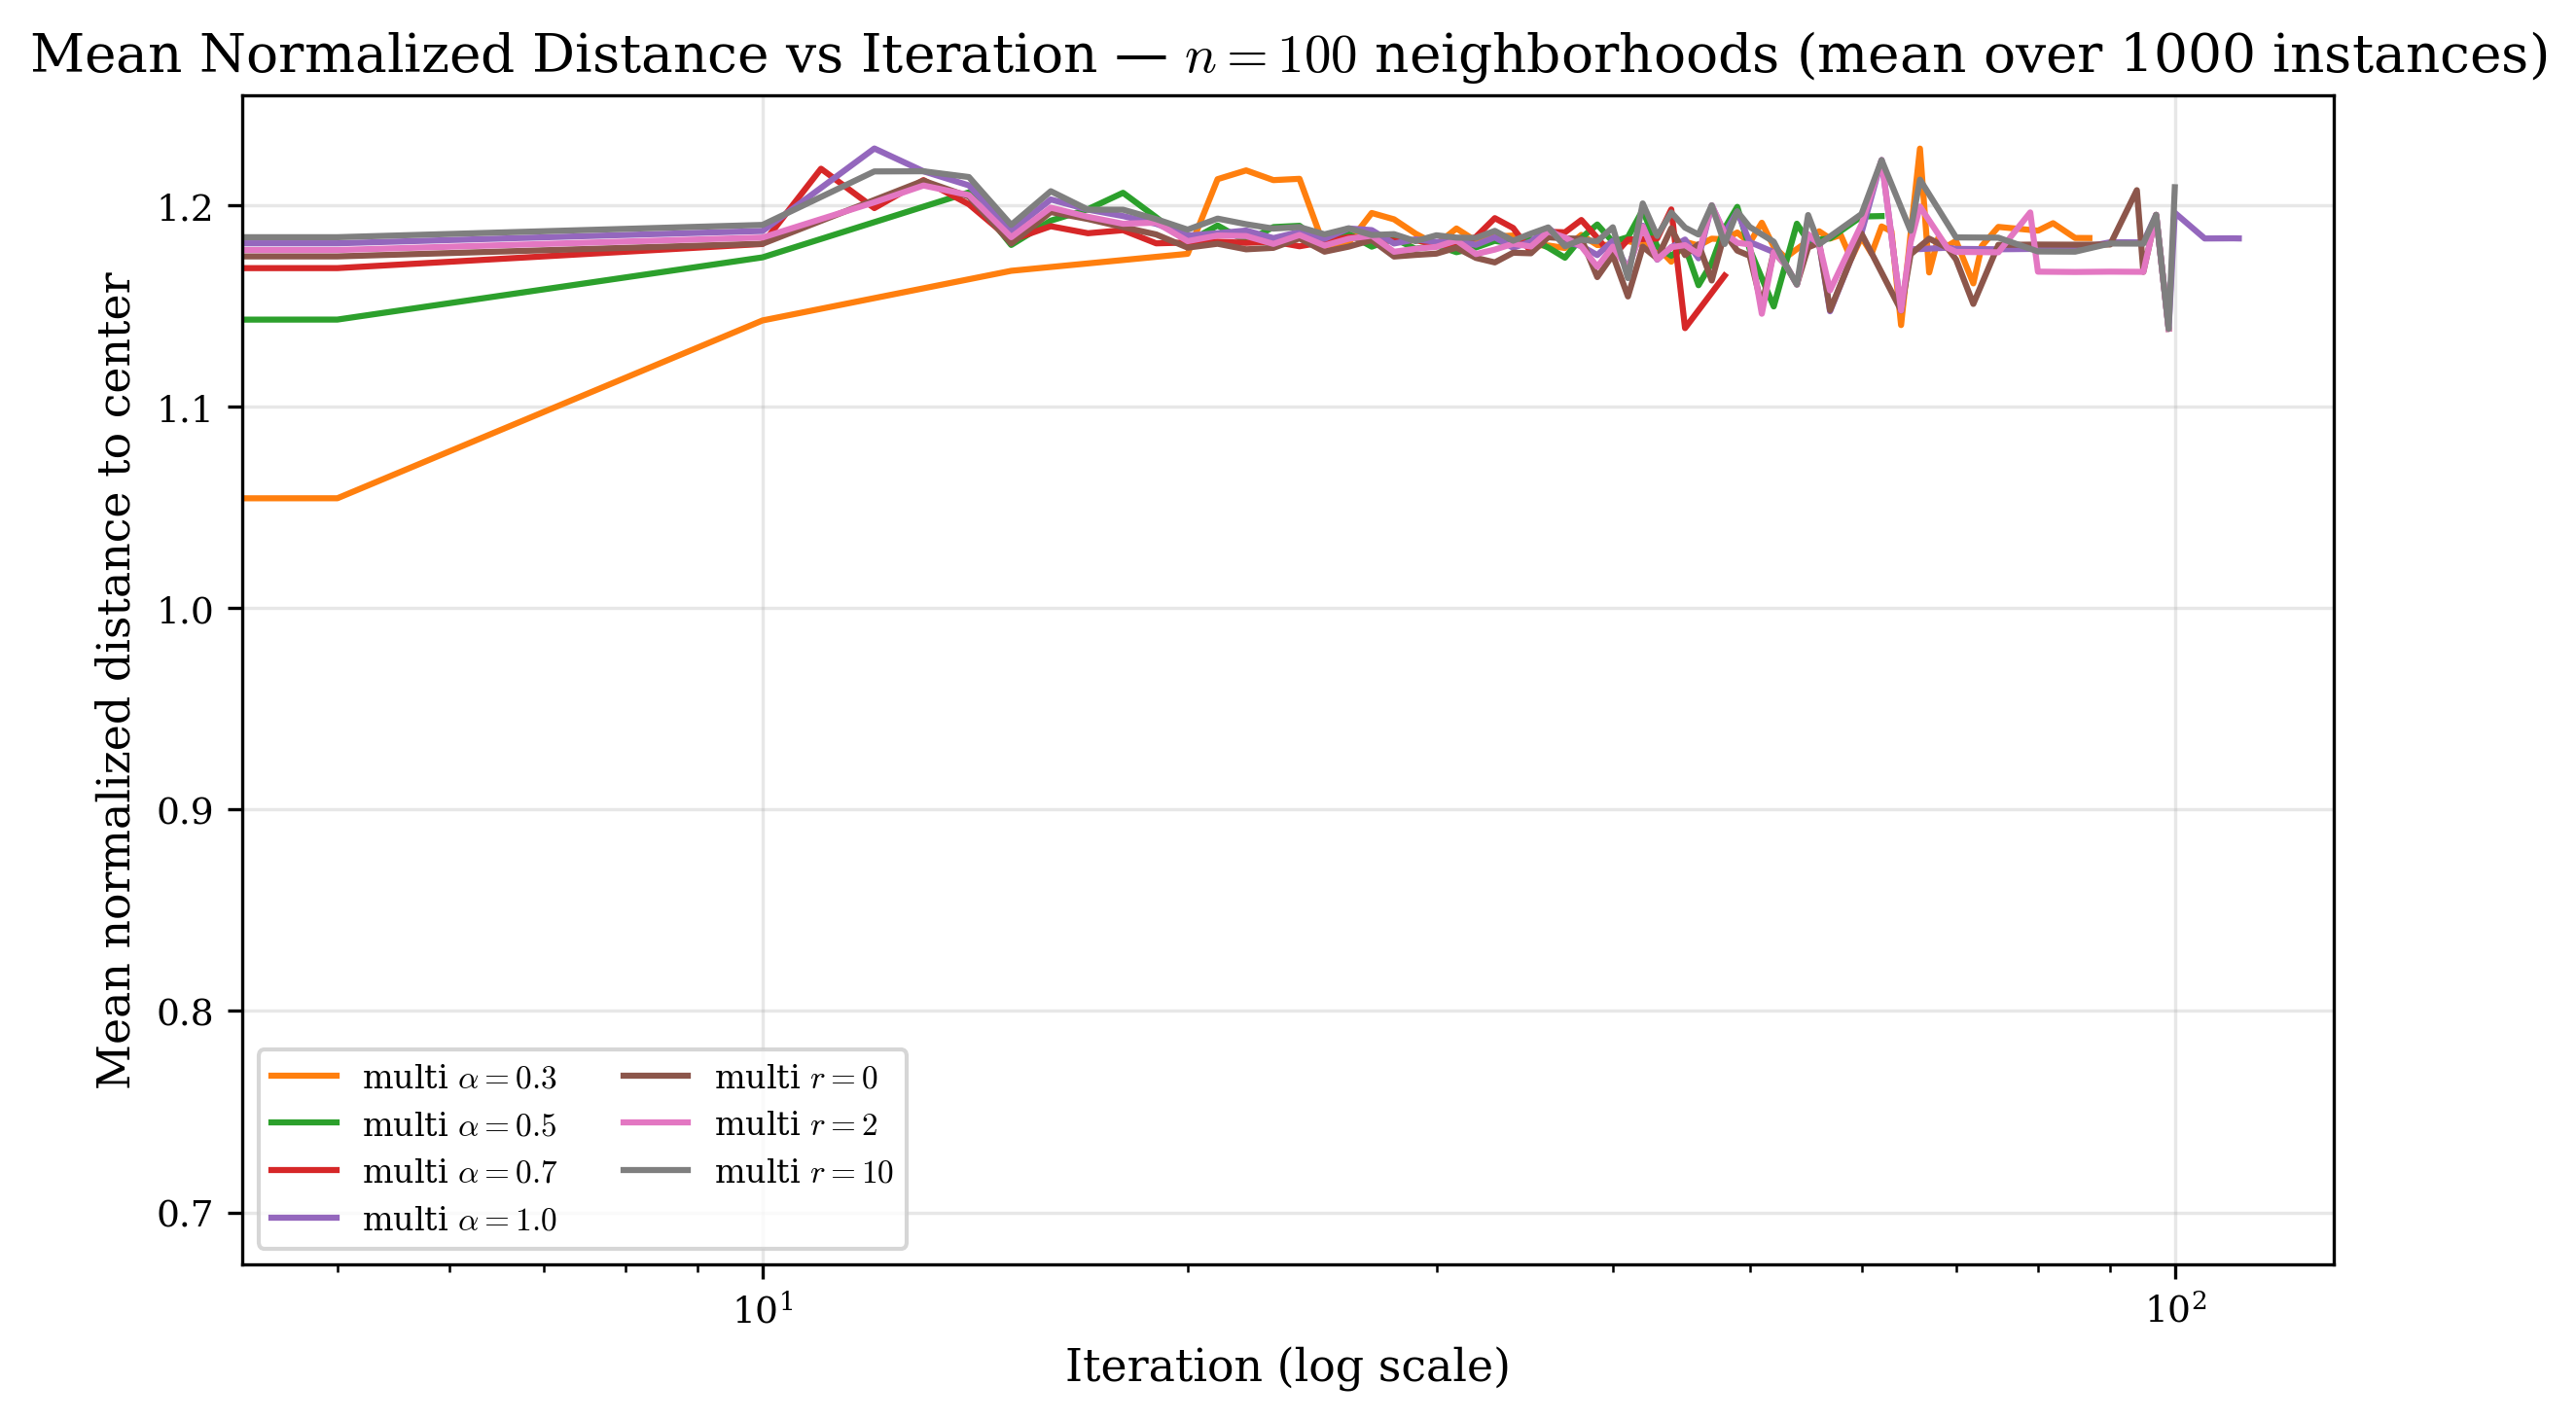

In [36]:
mean_nd = (
    df_iter[
        (df_iter["n"] == 100) &
        (~df_iter["label"].str.contains("best", na=False)) &
        (df_iter["iter"] < 9999)
    ]
    .groupby(["label", "iter"])["mean_norm_dist"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
for lbl in ORDER_NO_BEST:
    sub = mean_nd[mean_nd["label"] == lbl].sort_values("iter")
    ax.plot(sub["iter"], sub["mean_norm_dist"], label=lbl, color=COLOR[lbl])

ax.set_xscale("log")
ax.set_xlabel("Iteration (log scale)")
ax.set_ylabel("Mean normalized distance to center")
ax.set_title(r"Mean Normalized Distance vs Iteration — $n = 100$ neighborhoods (mean over 1000 instances)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
save(fig, "09_norm_dist_vs_iter")
plt.show()

Saved → plots/10_boundary_vs_quality.png


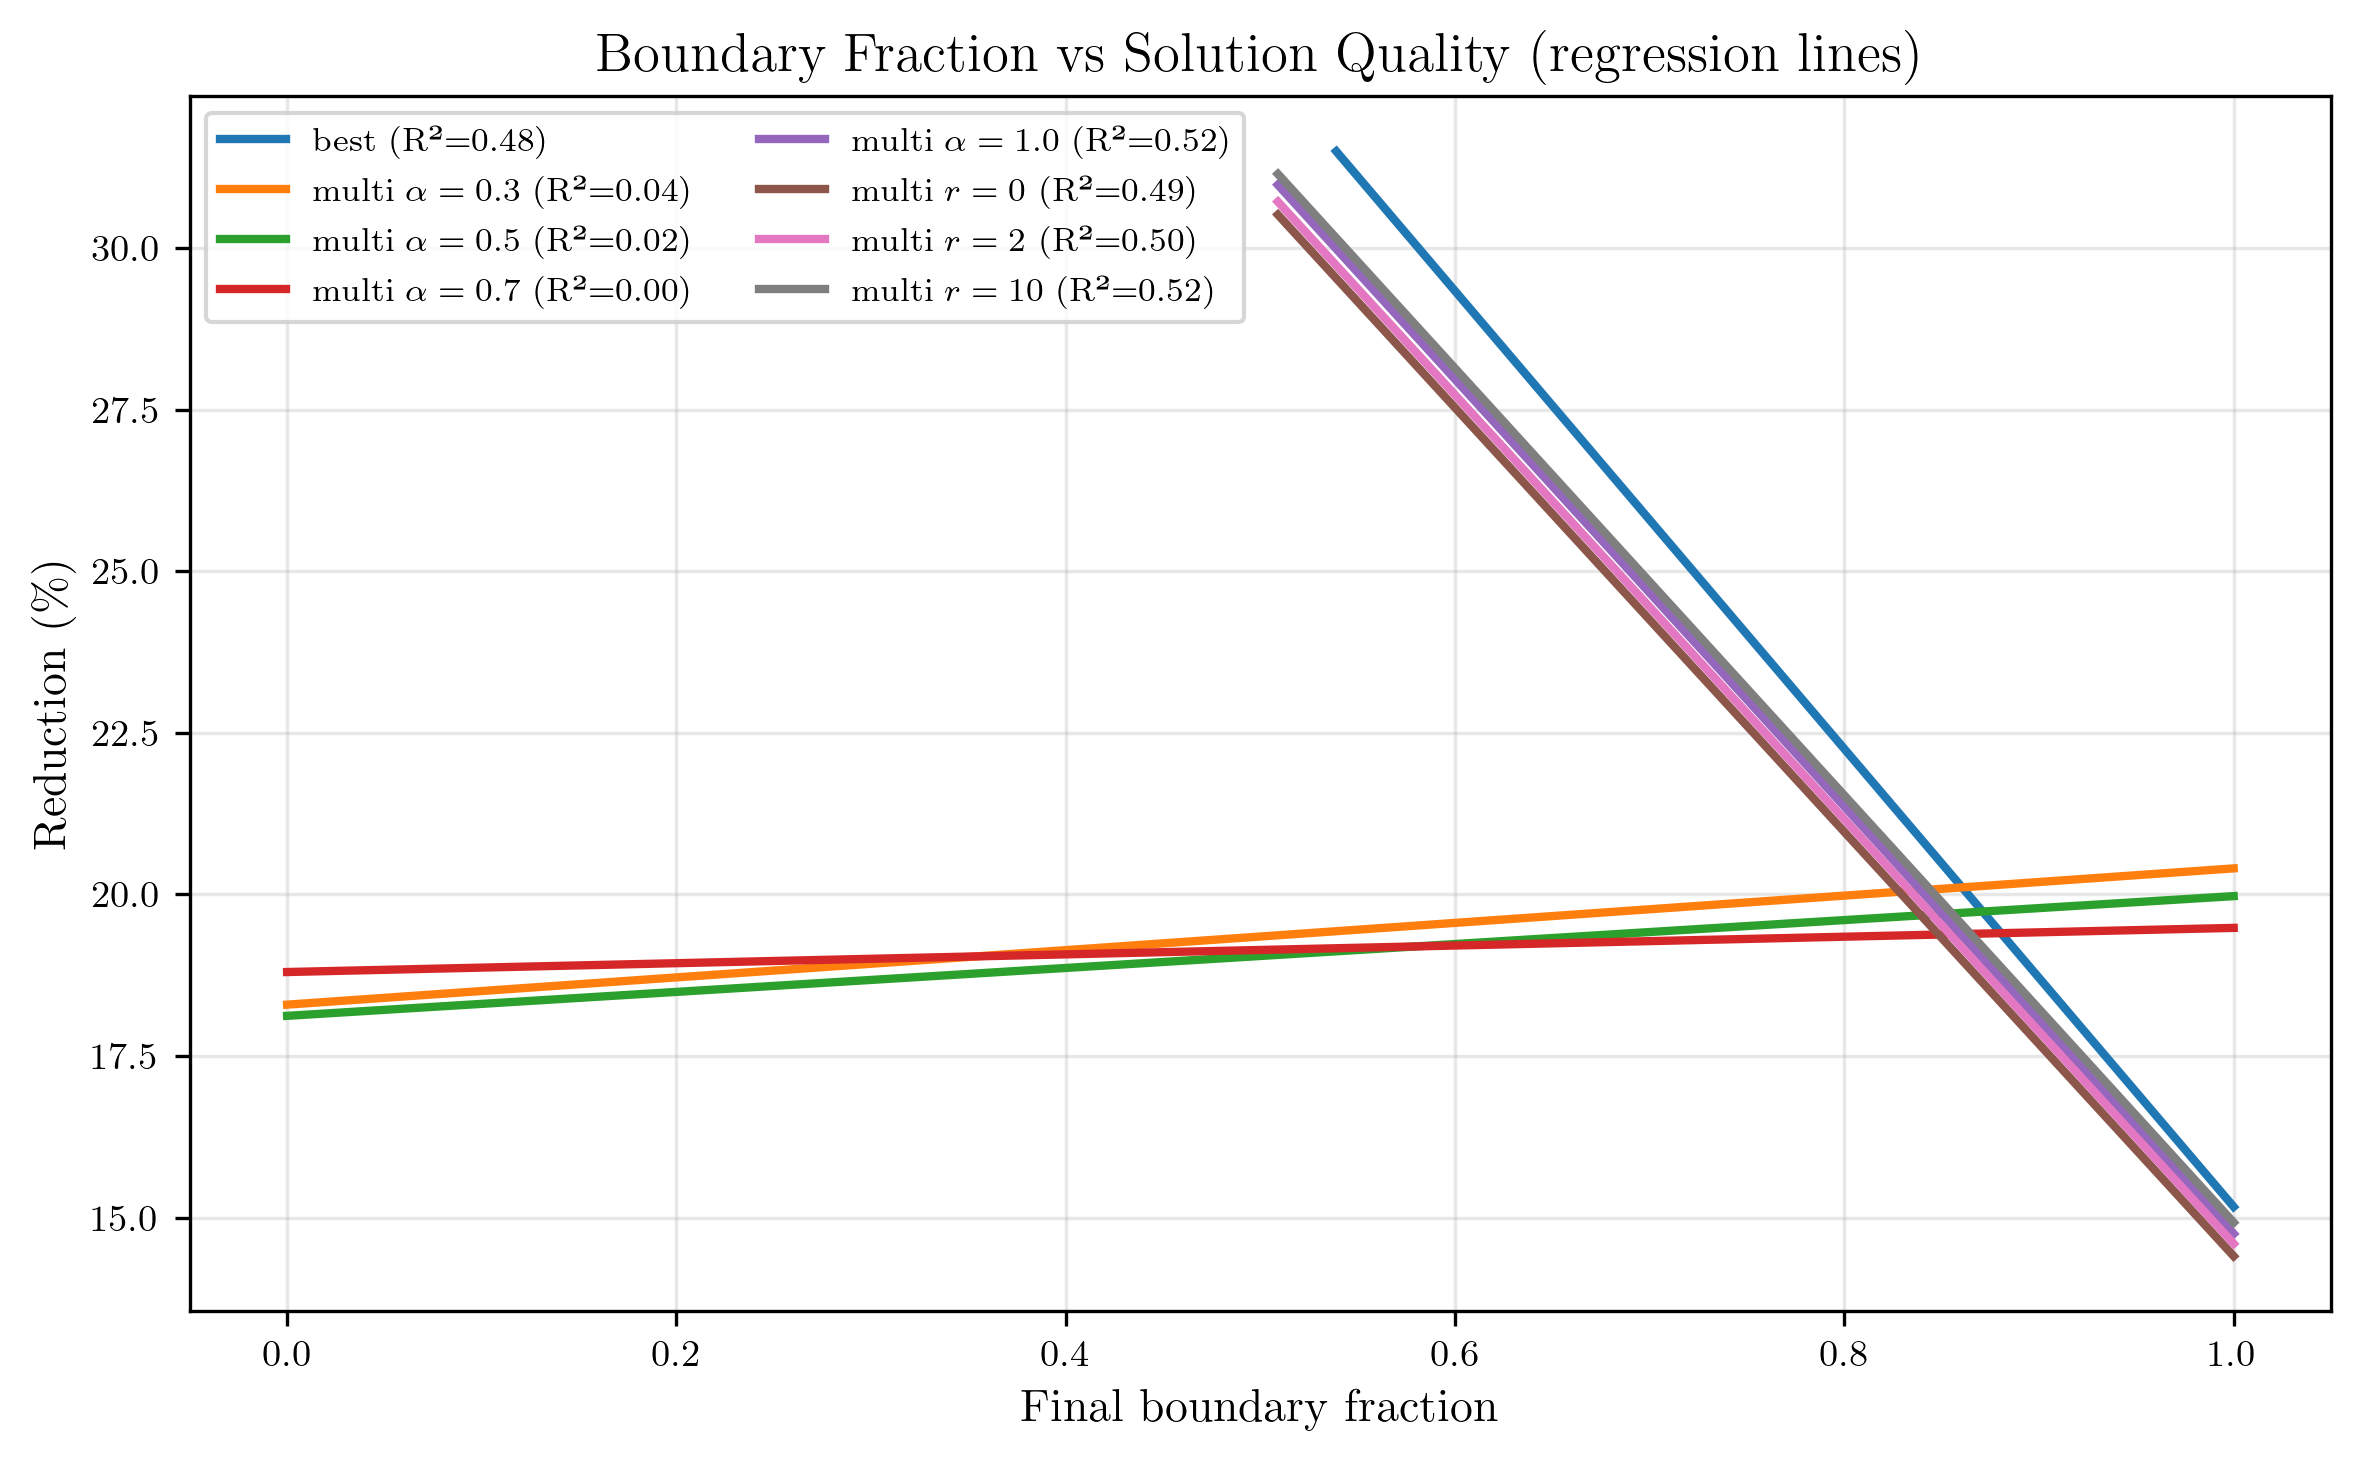

In [69]:
fig, ax = plt.subplots(figsize=(8, 5))
for lbl in ORDER_ALL:
    sub = df[df["label"] == lbl].dropna(subset=["final_frac_boundary", "reduction_pct"])
    if len(sub) < 5:
        continue
    
    # Régression linéaire
    m_fit = np.polyfit(sub["final_frac_boundary"], sub["reduction_pct"], 1)
    x_fit = np.linspace(sub["final_frac_boundary"].min(),
                        sub["final_frac_boundary"].max(), 100)
    y_fit = np.polyval(m_fit, x_fit)
    
    # Coefficient R²
    corr = np.corrcoef(sub["final_frac_boundary"], sub["reduction_pct"])[0,1]
    r2   = corr ** 2
    
    ax.plot(x_fit, y_fit, color=COLOR[lbl], linewidth=2,
            label=f"{lbl} (R²={r2:.2f})")

ax.set_xlabel("Final boundary fraction")
ax.set_ylabel(r"Reduction (\%)")
ax.set_title("Boundary Fraction vs Solution Quality (regression lines)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
save(fig, "10_boundary_vs_quality")
plt.show()

/tmp/ipykernel_37756/1882404843.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_by_n = df.groupby("n").apply(


Saved → plots/11_corr_normdist_reduction.png


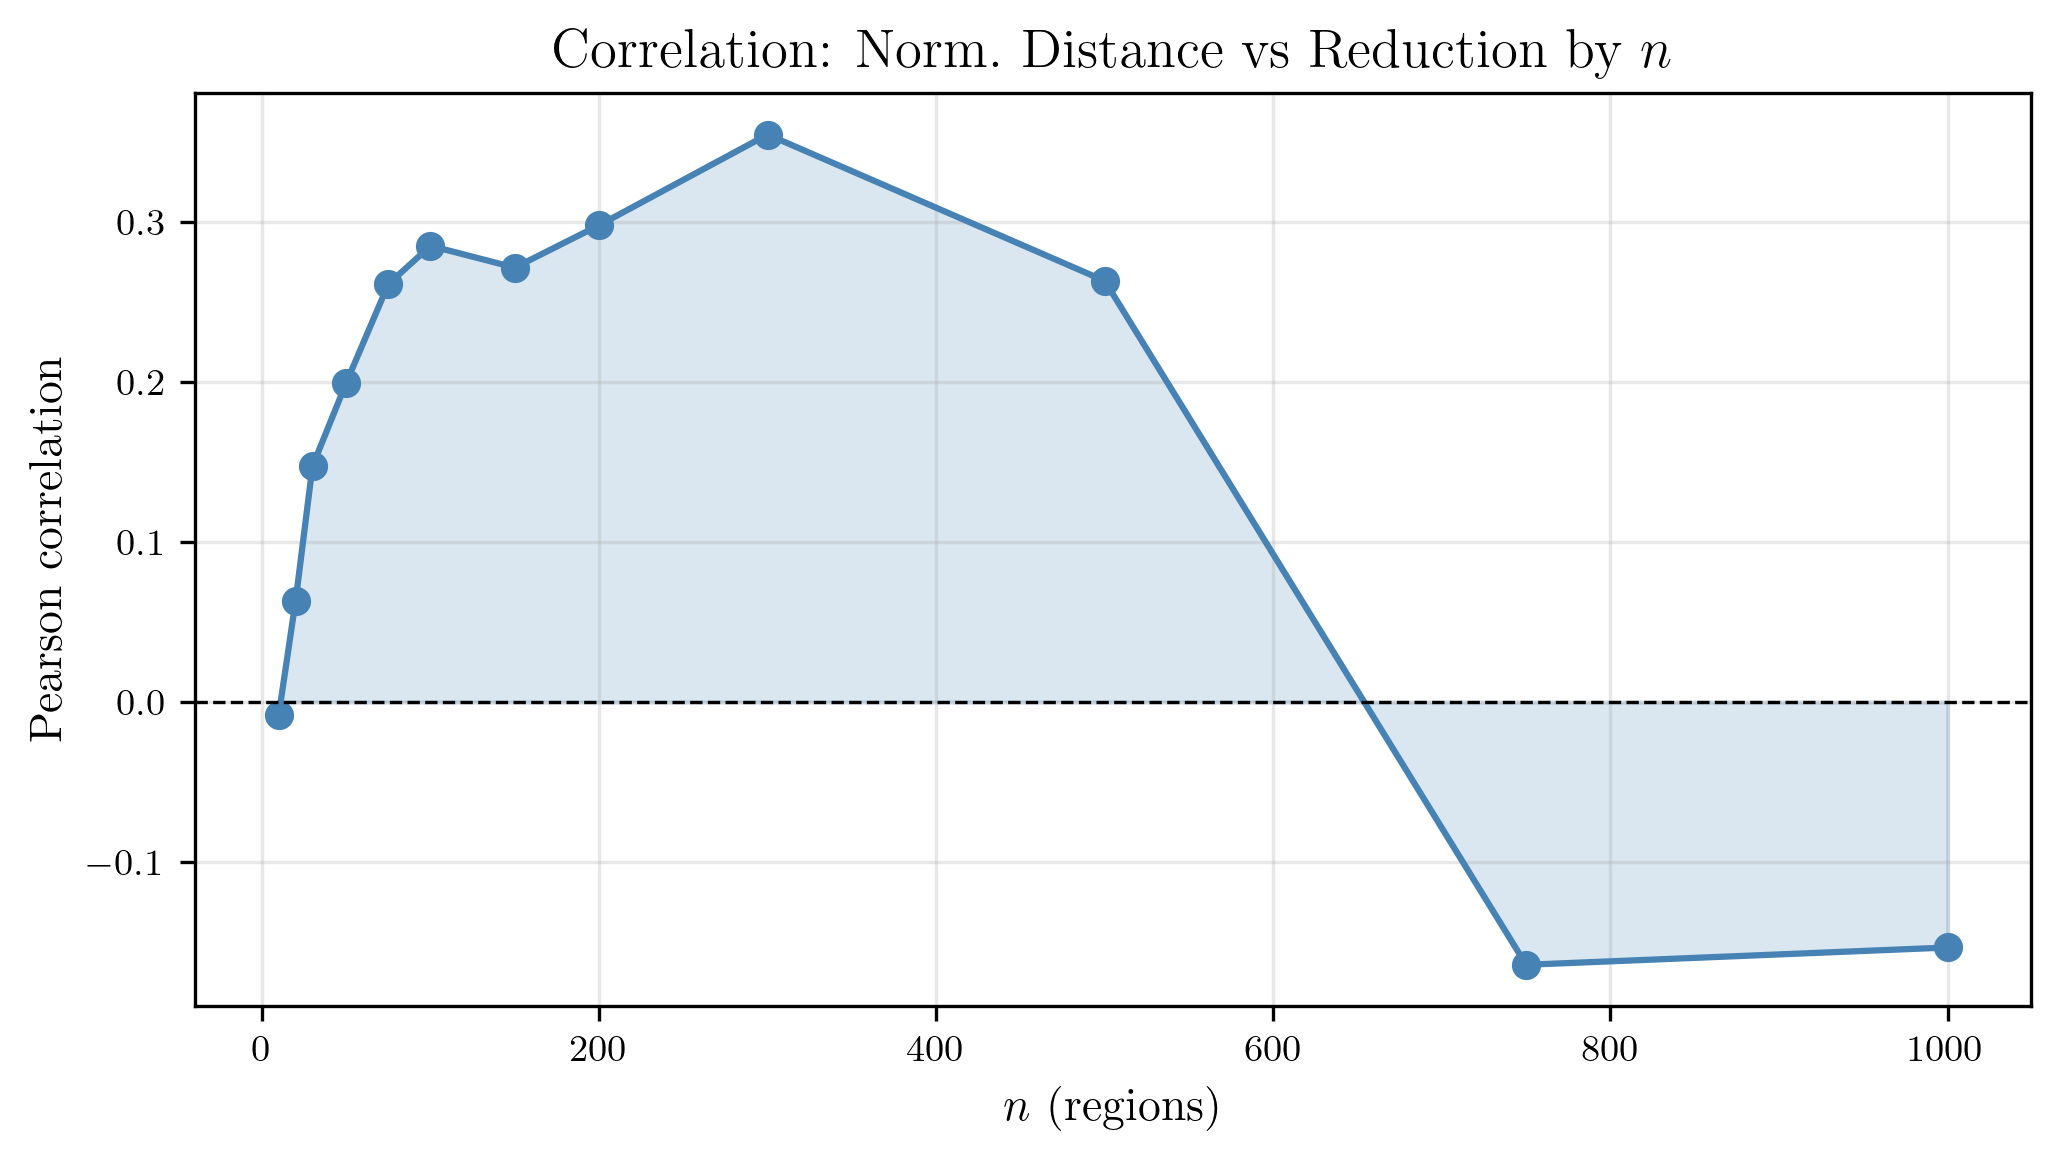

In [32]:
corr_by_n = df.groupby("n").apply(
    lambda g: g[["final_mean_norm_dist","reduction_pct"]].corr().iloc[0,1]
).reset_index(name="correlation")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(corr_by_n["n"], corr_by_n["correlation"], marker="o", color="steelblue")
ax.fill_between(corr_by_n["n"], corr_by_n["correlation"], alpha=0.2, color="steelblue")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel(r"$n$ (regions)")
ax.set_ylabel("Pearson correlation")
ax.set_title(r"Correlation: Norm.\ Distance vs Reduction by $n$")
plt.tight_layout()
save(fig, "11_corr_normdist_reduction")
plt.show()

Saved → plots/13_dominance_matrix.png


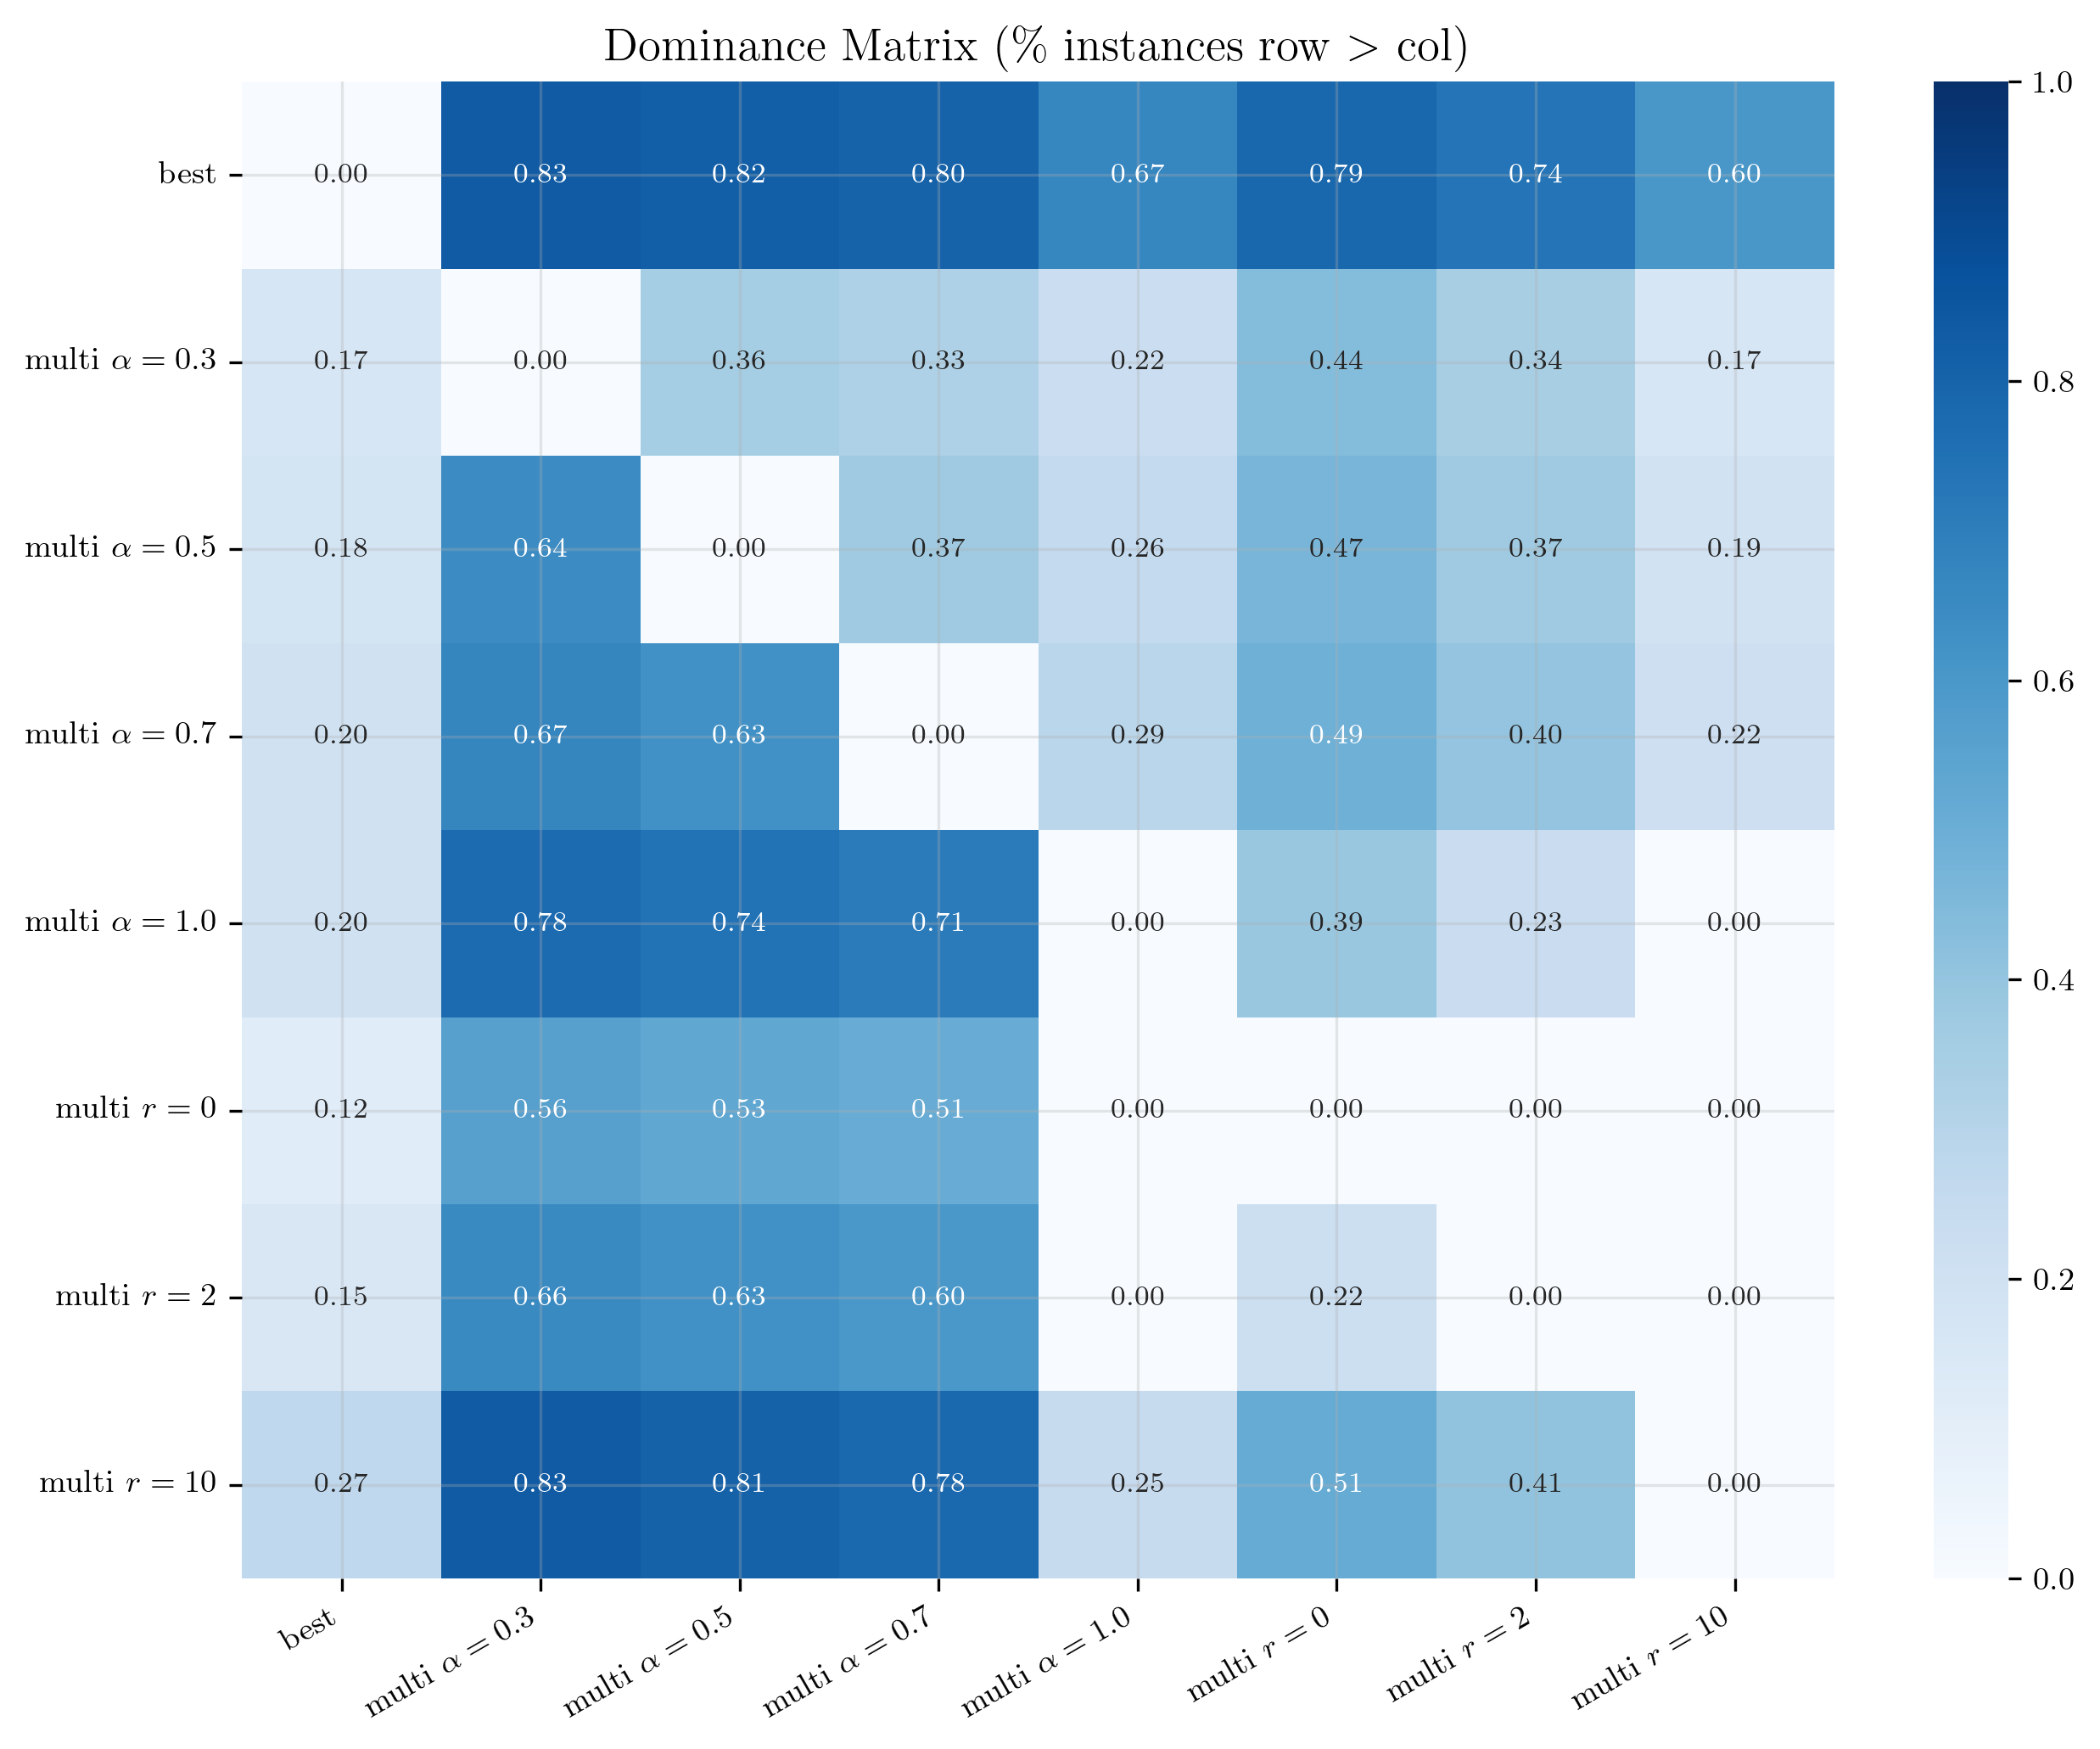

In [33]:
configs_list = [c for c in NICE.keys() if c in df["config_key"].unique()]
pivot        = df.pivot_table(index="instance_id", columns="config_key",
                               values="reduction_pct")
n_cfg = len(configs_list)
mat   = np.zeros((n_cfg, n_cfg))
for i, ci in enumerate(configs_list):
    for j, cj in enumerate(configs_list):
        if ci in pivot.columns and cj in pivot.columns:
            mat[i,j] = (pivot[ci] > pivot[cj]).mean()

labels = [NICE[c] for c in configs_list]
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(mat, annot=True, fmt=".2f", xticklabels=labels, yticklabels=labels,
            cmap="Blues", vmin=0, vmax=1, ax=ax,
            annot_kws={"size": 8})
ax.set_title(r"Dominance Matrix (\% instances row $>$ col)")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
save(fig, "13_dominance_matrix")
plt.show()

# MSTN Heuristic — Experimental Analysis

## 1. Context and Problem

The **Minimum Spanning Tree with Neighborhoods (MSTN)** problem is a generalization of the classical MST: instead of fixed vertex positions, each vertex $i$ is associated with a convex region (here, an axis-aligned square neighborhood $N_i$). The goal is to jointly select one **representative point** $y_i \in N_i$ per neighborhood and a **spanning tree** $T$ on those representatives, minimizing the total Euclidean edge length:

$$\min_{y_i \in N_i,\, T} \sum_{(i,j) \in T} \|y_i - y_j\|$$

The problem is **NP-hard** in general. Its key structural property is **biconvexity**: fixing the tree makes the position subproblem convex (a projection problem), and fixing the positions makes the tree subproblem a classical MST (solvable by Kruskal's algorithm in $O(|E| \log |E|)$).

The implemented heuristic exploits this structure by **alternating**:
1. Compute MST on current representative positions.
2. Move each representative toward the **barycenter of its tree-neighbors**, projected back onto its square neighborhood.
3. Repeat until convergence (displacement < tolerance) or max iterations reached.

Multiple strategies are compared:
- **`best`**: keep the best solution found across multiple independent runs from the same initialization (centers).
- **`multistart`**: run the heuristic from multiple random initializations, return the best.
  - Parameter $\alpha \in \{0.3, 0.5, 0.7, 1.0\}$: fraction of random perturbation in initialization.
  - Parameter $r \in \{0, 2, 5, 10\}$: number of random restarts.

The **reduction** metric is defined as:

$$\text{reduction} = 100 \times \frac{\text{MST cost at centers} - \text{MSTN heuristic cost}}{\text{MST cost at centers}} \quad (\%)$$

---

## 2. Dataset Description

| n | Instances | Configs | Grid size | s_min | s_max | Total rows |
|---|---|---|---|---|---|---|
| 10 | 1000 | 10 | 50 | 2 | 5 | 10 000 |
| 20 | 1000 | 10 | 63 | 2 | 6 | 10 000 |
| 30 | 1000 | 10 | 77 | 2 | 6 | 10 000 |
| 50 | 1000 | 10 | 99 | 3 | 6 | 10 000 |
| 75 | 1000 | 10 | 121 | 4 | 6 | 10 000 |
| 100 | 1000 | 10 | 140 | 4 | 6 | 10 000 |
| 150 | 503 | 10 | 171 | 5 | 6 | 5 030 |
| 200 | 403 | 10 | 198 | 6 | 7 | 4 030 |
| 300 | 200 | 9 | 242 | 7 | 8 | 1 800 |
| 500 | 100 | 8 | 313 | 9 | 10 | 800 |
| 750 | 96 | 8 | 383 | 11 | 12 | 768 |
| 1000 | 97 | 8 | 443 | 13 | 14 | 776 |

**Reading guide:**
- $n$ = number of neighborhoods (vertices).
- Grid size = spatial extent of the square grid; grows with $n$ to maintain fixed density.
- $s_{\min}$, $s_{\max}$ = min/max side length of square neighborhoods; also grow with $n$.
- Instance count decreases for large $n$ due to computational cost.
- All instances use a **complete graph** ($|E| = n(n-1)/2$).

**Key observation:** as $n$ grows, neighborhoods become larger relative to the grid, increasing the potential gain from optimally placing representatives — this explains why reduction percentages grow with $n$.

---

## 3. Plot-by-Plot Analysis

### Fig. 1 — Solution Quality by Configuration (Boxplot)

**What it shows:** Distribution of reduction (%) across all instances and all $n$, for each configuration.

**Analysis:** All configurations achieve a median reduction near **19%**. The `best` configuration shows a slightly higher upper quartile (~21%) and a wider interquartile range. The `multi alpha=0.3` configuration has slightly lower performance. Differences between configs are small in aggregate because the dataset mixes all problem sizes — the signal is much clearer when conditioning on $n$ (see Fig. 2).

---

### Fig. 2 — Median Reduction vs Problem Size

**What it shows:** How median reduction grows with $n$, split by effect of alpha (left) and effect of $r$ (right).

**Analysis:**
- **Left (effect of alpha):** Reduction grows consistently from ~16% at $n=10$ to ~36% at $n=1000$ for all configurations. `best` consistently dominates. Among multistart variants, differences in alpha are minimal once $r=5$ restarts are used.
- **Right (effect of $r$):** `multi r=0` (no restarts) performs slightly below the others, especially at large $n$. Adding even $r=2$ restarts nearly closes the gap. `multi r=10` matches `best` closely at $n=1000$.

**Key insight:** The reduction gain with $n$ is explained by the proportional growth of neighborhood sizes — larger neighborhoods give the heuristic more freedom to relocate representatives.

---

### Fig. 3 — Iterations to Convergence

**What it shows:** Distribution of the number of iterations until convergence for each configuration (log scale on y-axis).

**Analysis:** Median convergence is between **15 and 35 iterations** across all configs. The `best` strategy has the heaviest tail (up to $10^4$ iterations) on large or hard instances. `multi alpha=0.7` and `multi alpha=1.0` converge fastest.

**Key insight:** The heuristic is extremely fast in typical cases, converging in a few dozen iterations — validating its practical scalability.

---

### Fig. 4 — Runtime vs Problem Size

**What it shows:** Median runtime (seconds) as a function of $n$ for each configuration.

**Analysis:** Runtime is negligible for $n < 200$ (< 10s). It grows super-linearly from $n=500$, consistent with $O(K \cdot n^2 \log n)$ complexity (complete graph, Kruskal per iteration). At $n=1000$: `best` and `multi alpha=0.3` reach ~7000–8000s, while `multi r=0` stays around 3300s.

**Key insight:** Clear **quality/speed tradeoff** controlled by $r$: more restarts = better quality but higher runtime.

---

### Fig. 5 — Performance Profile (Dolan-Moré)

**What it shows:** For each configuration, the fraction of instances where its solution is within a factor $\tau$ of the best known solution across all configs.

**Reading guide:** At $\tau = 1.0$, the y-value = fraction of instances where this config achieves the **best solution**. A higher curve = better overall performance.

**Analysis:** `best` reaches ~50% at $\tau=1$ (top solution on half of instances) and dominates for $\tau < 1.05$. `multi r=10` is close behind (~20% at $\tau=1$). `multi alpha=0.3` has the worst profile. Most configs are within 5% of the best on ~90% of instances, showing the heuristic is **robust across variants**.

---

### Fig. 6 — Cost Convergence (averaged over instances)

**What it shows:** Mean normalized cost $c_k / c_0$ over iterations (log scale), averaged over all instances.

**Analysis:** All configs start near 1.0 and converge toward ~0.98. The apparent oscillations in `best` for $k > 100$ are an **artifact of averaging**: small instances converge early and drop out, leaving large instances with high variance to dominate. The main improvement phase occurs between $k=10$ and $k=200$.

---

### Fig. 7 — Spatial Distribution of Representatives over Iterations (All Configs)

**What it shows:** For each configuration, evolution of the fraction of representatives classified as **Center**, **Interior**, or **Boundary** over iterations, averaged over all instances (with forward-fill for converged instances). Each subplot has its own x-axis adapted to the config's actual convergence horizon.

**Analysis:**

The most striking observation is the **strong dependence of convergence speed on alpha**:

| Config | Max iterations |
|---|---|
| multi alpha=0.7 | 151 |
| multi alpha=0.5 | 198 |
| multi alpha=0.3 | 297 |
| multi alpha=1.0 / r=0 / r=2 / r=10 | ~270 |
| best | 9999 |

Configs with **small alpha** (e.g., 0.3) initialize representatives close to neighborhood centers (less perturbation), so they are already in a near-feasible region and converge faster — but at the cost of lower solution diversity and slightly worse final quality. Configs with **large alpha** (1.0) start from more perturbed positions, require more iterations to stabilize but explore more of the solution space.

In all configs, the dynamic is qualitatively similar:
- **Iteration 1**: nearly all representatives immediately jump to **Boundary** (~95–100%), as the barycenter of all neighbors in the complete initial graph pulls them outward.
- **Early phase (iter 2–50)**: strong oscillations between Interior and Boundary as the tree structure rapidly reorganizes. The amplitude of oscillations is larger for small alpha configs.
- **Late phase**: progressive stabilization, with Interior growing to ~40–50% and Boundary settling at ~50–55%. This reflects the final tree structure where representatives are pulled toward adjacent neighborhoods.

The **`best`** config stands apart — its x-axis extends to ~10 000 iterations because it stores and compares runs across all restarts, including very hard large instances that take thousands of iterations to converge.

---

### Fig. 8 — Boundary Fraction vs Iteration by Config

**What it shows:** Mean fraction of representatives on the neighborhood boundary per iteration (log scale).

**Analysis:** All configs start near 96–97% boundary and decrease toward 50–88% at convergence. `best` maintains the highest boundary fraction (~88%) due to restarts. `multi r=0` stabilizes lowest (~52%). Low-alpha configs show strong early oscillations from their perturbed initializations.

---

### Fig. 9 — Mean Normalized Distance to Center vs Iteration

**What it shows:** Mean normalized distance of representatives to their neighborhood center per iteration (log scale). A value > 1 means representatives are on average farther from the center than half the neighborhood side length.

**Analysis:** Representatives do not converge to the center — they stabilize **near the boundaries** (final distance ~1.24). This is geometrically necessary to minimize inter-neighborhood edge lengths by bringing adjacent representatives as close as possible.

---

### Fig. 10 — Boundary Fraction vs Solution Quality (regression lines)

**What it shows:** Linear regression of reduction (%) against final boundary fraction, one line per config. $R^2$ values shown in legend.

**Analysis:**
- `multi alpha=0.3/0.5/0.7`: near-zero slope and $R^2 \approx 0$ — boundary fraction has no predictive power.
- `best`, `multi alpha=1.0`, `multi r=*`: strong **negative slopes** ($R^2 \approx 0.48–0.52$) — higher boundary fraction is associated with *lower* reduction.

**Interpretation:** The best solutions have a **mix** of interior and boundary representatives. Solutions where all representatives are pushed to boundaries may be stuck in local minima with suboptimal tree structures.

---

### Fig. 11 — Correlation: Norm. Distance vs Reduction by n

**What it shows:** Pearson correlation between final mean normalized distance and reduction (%), computed separately for each $n$.

**Analysis:**
- **Near zero** at $n=10$ (too much variance).
- **Positive (~0.25–0.35)** for $n \in [30, 500]$: moving further from center improves solution.
- **Negative (~-0.15)** for $n \geq 750$: the relationship **reverses** for large instances.

**Interpretation:** A **structural phase transition** around $n=500$: for large instances, the high density of the complete graph makes extreme displacements conflicting — the optimal strategy shifts toward more moderate interior placements.

---

### Fig. 12 — Dominance Matrix

**What it shows:** Entry $[i, j]$ = fraction of instances where configuration $i$ strictly outperforms configuration $j$.

**Analysis:**
- `best` dominates all others on 60–83% of instances.
- `multi r=10` is the best multistart variant, reaching 0.25 over `multi alpha=1.0`.
- `multi alpha=0.3` is the weakest variant.
- The zero-block between `multi r=0`, `multi r=2`, and `multi alpha=1.0` shows these configs are nearly equivalent.

---

## 4. Conclusion

The alternating heuristic for MSTN demonstrates **strong and consistent performance** across all tested configurations and problem sizes:

- **Reduction grows robustly with $n$**: from ~16% at $n=10$ to ~36% at $n=1000$, driven by proportional neighborhood size growth.
- **Convergence is fast**: median 15–35 iterations, runtime dominated by Kruskal ($O(n^2 \log n)$ per iteration on complete graphs).
- **Alpha controls the exploration/convergence tradeoff**: small alpha (0.3) converges in fewer iterations but explores less of the solution space, yielding slightly worse solutions. Large alpha (1.0) requires more iterations but achieves better quality. This mirrors the temperature schedule in simulated annealing or the initialization strategy in k-means.
- **Restarts matter more than alpha**: $r$ (number of restarts) has a clearer impact on quality than the perturbation magnitude. `multi r=10` nearly matches `best` for large $n$.
- **Representatives stabilize near boundaries** (~50–90% boundary), but optimal solutions **balance** interior and boundary placements — excessive boundary fraction correlates with lower quality.
- **A structural transition around $n \approx 500$**: the relationship between representative displacement and solution quality reverses sign for large instances, suggesting a qualitative change in optimal placement strategy.

**Practical recommendation:** For $n < 500$, `multi alpha=1.0 r=5` offers a good quality/speed tradeoff. For $n \geq 500$ where quality is critical, `multi r=10` is preferred despite higher runtime. The `best` strategy remains the gold standard but requires storing and comparing multiple independent runs.

---

## References

[1] V. Blanco, E. Fernandez, J. Puerto. *Minimum Spanning Trees with neighborhoods: Mathematical programming formulations and solution methods.* European Journal of Operational Research, 262 (2017), 863–878.